# Drug Discovery Pipeline (Optimized)
## Quantum-Enhanced Multimodal Drug Discovery with Graph Neural Networks

### Architecture Overview
```
Multimodal Embeddings ──→ Transfer Learning ──→ Core Neural ──→ Model Engines ──→ Generation & Prediction
     from P1                Module + PTMs       Architectures     ├─ Graph Diffusion   ├─ De Novo SMILES
                                                    │             │  Engine (DiffRM)    │  Generation
Activity & ADMET ──→ PyTorch & PyG                  │             │  (12K+ molecules)   │  (Transformer w/
    Scoring            Training Pipeline             │             │                     │   cross-attention)
                                                     │             └─ Equivariant GNN   └─ Binding Affinity
                                                     ▼               (18K+ samples)        Predictor
                                              Optimized Candidate Molecules
                                     (SA Score + Novelty + Multi-Objective Ranking)
```

### Datasets
| Dataset | Records | Purpose |
|---------|---------|--------|
| drug_cleaned.csv | 76,543 | Docking scores + molecular descriptors |
| drug_filtered.csv | 637,292 | Filtered drug candidates |
| interactions_cleaned.csv | 750 | Drug-protein interactions |
| drug_protein_diagnosis.csv | 99 | Drug-protein binding with diagnosis |
| drug_protein_binding (1).csv | ~5,000 | Drug-protein binding with real Ki/IC50/Kd and pKi |
| Kd_bind.tsv | ~57,000 | Kd binding affinity data from BindingDB |
| tox21_cleaned.csv | 7,831 | Toxicity assay data (12 endpoints) |
| clintox.csv | 1,484 | Clinical toxicity (FDA approval + CT toxicity) |

---
## 1. Setup & Installation

In [1]:
!unzip archive.zip

Archive:  archive.zip
  inflating: EC50_bind.tsv           
  inflating: IC50_bind.tsv           
  inflating: Kd_bind.tsv             
  inflating: Ki_bind.tsv             


In [2]:
# Install required packages (uncomment as needed)
!pip install torch torch-geometric rdkit scikit-learn pandas numpy matplotlib seaborn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 19.6 MB/s eta 0:00:00


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR

# PyTorch Geometric
import torch_geometric
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_add_pool
from torch_geometric.loader import DataLoader as PyGDataLoader

# RDKit for molecular processing
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw, DataStructs
from rdkit.Chem import rdMolDescriptors

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, accuracy_score, mean_squared_error,
                             classification_report, r2_score)

from tqdm.auto import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')
print(f'PyG version: {torch_geometric.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128
PyG version: 2.7.0


---
## 2. Data Loading & Exploration

In [4]:
# Load all datasets
DATA_DIR = '.'

drug_cleaned = pd.read_csv(os.path.join(DATA_DIR, '/content/drug_cleaned.csv'))
drug_filtered = pd.read_csv(os.path.join(DATA_DIR, '/content/drug_filtered.csv'))
interactions = pd.read_csv(os.path.join(DATA_DIR, '/content/interactions_cleaned.csv'))
drug_protein = pd.read_csv(os.path.join(DATA_DIR, '/content/drug_protein_diagnosis.csv'))
tox21 = pd.read_csv(os.path.join(DATA_DIR, '/content/tox21_cleaned.csv'))
clintox = pd.read_csv(os.path.join(DATA_DIR, '/content/clintox.csv'))

# New datasets: drug-protein binding with real affinities
drug_protein_binding = pd.read_csv(os.path.join(DATA_DIR, '/content/drug_protein_binding (1).csv'))
kd_bind = pd.read_csv(os.path.join(DATA_DIR, '/content/Kd_bind.tsv'), sep='\t')

print('=== Dataset Shapes ===')
for name, df in [('drug_cleaned', drug_cleaned), ('drug_filtered', drug_filtered),
                  ('interactions', interactions), ('drug_protein', drug_protein),
                  ('tox21', tox21), ('clintox', clintox),
                  ('drug_protein_binding', drug_protein_binding),
                  ('kd_bind', kd_bind)]:
    print(f'{name:30s} → {df.shape[0]:>8,} rows × {df.shape[1]:>3} cols')

=== Dataset Shapes ===
drug_cleaned                   →   76,543 rows ×  16 cols
drug_filtered                  →  637,292 rows ×  16 cols
interactions                   →      750 rows ×  16 cols
drug_protein                   →       99 rows ×   7 cols
tox21                          →    7,831 rows ×  16 cols
clintox                        →    1,484 rows ×   3 cols
drug_protein_binding           →    5,000 rows ×  17 cols
kd_bind                        →   57,002 rows ×   6 cols


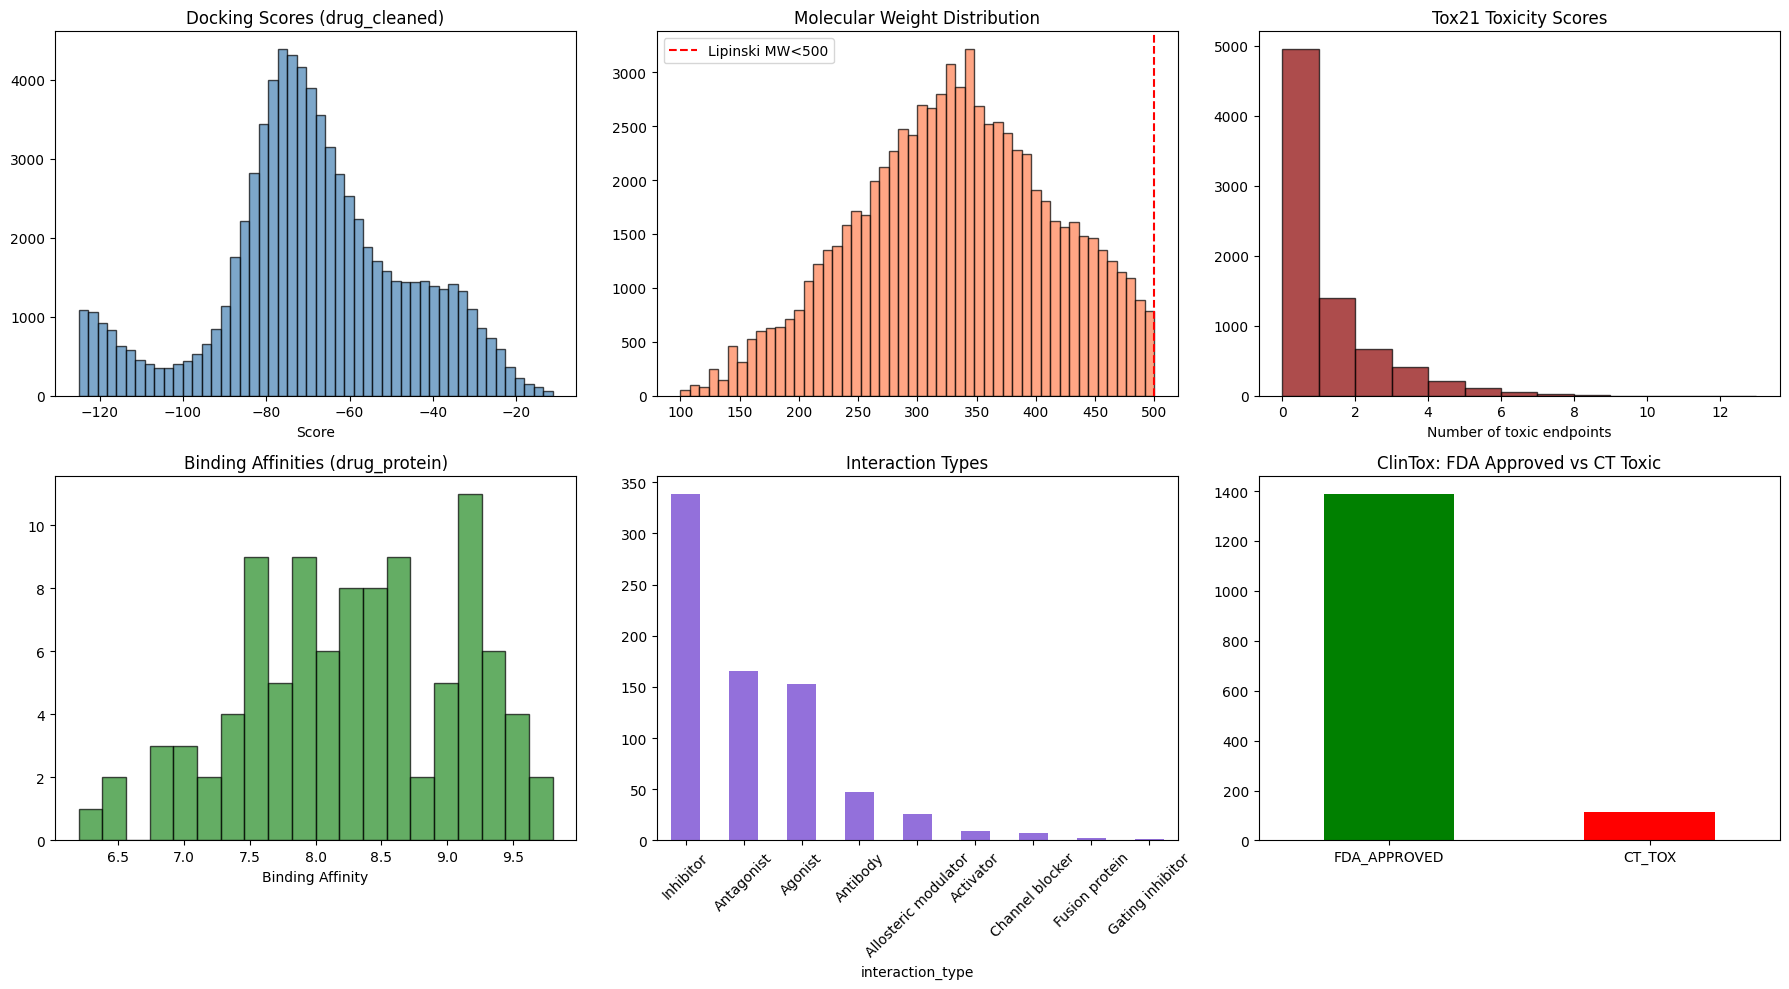

In [5]:
# Quick EDA
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Docking score distribution
axes[0, 0].hist(drug_cleaned['score'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Docking Scores (drug_cleaned)')
axes[0, 0].set_xlabel('Score')

# 2. MW distribution
axes[0, 1].hist(drug_cleaned['MW'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Molecular Weight Distribution')
axes[0, 1].axvline(x=500, color='red', linestyle='--', label='Lipinski MW<500')
axes[0, 1].legend()

# 3. Toxicity score distribution (tox21)
axes[0, 2].hist(tox21['toxicity_score'], bins=range(0, 14), color='darkred', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Tox21 Toxicity Scores')
axes[0, 2].set_xlabel('Number of toxic endpoints')

# 4. Binding affinity distribution
axes[1, 0].hist(drug_protein['binding_affinity'], bins=20, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Binding Affinities (drug_protein)')
axes[1, 0].set_xlabel('Binding Affinity')

# 5. Interaction types
interactions['interaction_type'].value_counts().plot.bar(ax=axes[1, 1], color='mediumpurple')
axes[1, 1].set_title('Interaction Types')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. ClinTox FDA approval vs toxicity
clintox_summary = clintox[['FDA_APPROVED', 'CT_TOX']].sum()
clintox_summary.plot.bar(ax=axes[1, 2], color=['green', 'red'])
axes[1, 2].set_title('ClinTox: FDA Approved vs CT Toxic')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 3. Multimodal Embeddings from P1
Generate molecular graph representations and fingerprint embeddings from SMILES.

In [6]:
# ─── Atom and Bond Feature Extraction ───

ATOM_FEATURES = {
    'atomic_num': list(range(1, 119)),
    'degree': [0, 1, 2, 3, 4, 5],
    'formal_charge': [-2, -1, 0, 1, 2],
    'hybridization': [
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2
    ],
    'num_hs': [0, 1, 2, 3, 4],
}

def one_hot_encode(value, choices):
    """One-hot encode a value given a list of possible choices."""
    encoding = [0] * (len(choices) + 1)  # +1 for unknown
    if value in choices:
        encoding[choices.index(value)] = 1
    else:
        encoding[-1] = 1
    return encoding


def get_atom_features(atom):
    """Extract atom-level features as a vector."""
    features = []
    features += one_hot_encode(atom.GetAtomicNum(), ATOM_FEATURES['atomic_num'])
    features += one_hot_encode(atom.GetDegree(), ATOM_FEATURES['degree'])
    features += one_hot_encode(atom.GetFormalCharge(), ATOM_FEATURES['formal_charge'])
    features += one_hot_encode(atom.GetHybridization(), ATOM_FEATURES['hybridization'])
    features += one_hot_encode(atom.GetTotalNumHs(), ATOM_FEATURES['num_hs'])
    features.append(1 if atom.GetIsAromatic() else 0)
    features.append(atom.GetMass() / 100.0)  # normalized mass
    return features


def get_bond_features(bond):
    """Extract bond-level features."""
    bt = bond.GetBondType()
    features = [
        bt == Chem.rdchem.BondType.SINGLE,
        bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE,
        bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(),
        bond.IsInRing()
    ]
    return [int(f) for f in features]


print(f'Atom feature dimension: {len(get_atom_features(Chem.MolFromSmiles("C").GetAtomWithIdx(0)))}')

Atom feature dimension: 146


In [7]:
# ─── SMILES → PyG Graph Conversion ───

def smiles_to_graph(smiles, y=None):
    """Convert a SMILES string to a PyG Data object with atom/bond features."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Atom features
    atom_feats = [get_atom_features(atom) for atom in mol.GetAtoms()]
    x = torch.tensor(atom_feats, dtype=torch.float)

    # Edge index and edge features
    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
        bf = get_bond_features(bond)
        edge_attr += [bf, bf]

    if len(edge_index) == 0:
        edge_index = torch.zeros((2, 0), dtype=torch.long)
        edge_attr = torch.zeros((0, 6), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    data.smiles = smiles

    if y is not None:
        data.y = torch.tensor([y], dtype=torch.float)

    return data


# Test conversion
test_graph = smiles_to_graph('CCO')
print(f'Test graph: {test_graph}')
print(f'  Nodes: {test_graph.num_nodes}, Edges: {test_graph.num_edges}')
print(f'  Node feature dim: {test_graph.x.shape[1]}')

Test graph: Data(x=[3, 146], edge_index=[2, 4], edge_attr=[4, 6], smiles='CCO')
  Nodes: 3, Edges: 4
  Node feature dim: 146


In [8]:
# ─── Multimodal Molecular Embedding (Fingerprints + Descriptors) ───

def get_morgan_fingerprint(smiles, radius=2, n_bits=2048):
    """Generate Morgan fingerprint (ECFP) for a SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(n_bits)
    gen = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = gen.GetFingerprintAsNumPy(mol)
    return fp.astype(np.float32)


def get_molecular_descriptors(smiles):
    """Compute physicochemical descriptors for a molecule."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return np.zeros(10)
    return np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.RingCount(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.NumAromaticRings(mol),
        Descriptors.HeavyAtomCount(mol)
    ], dtype=np.float32)


def get_multimodal_embedding(smiles, fp_bits=2048):
    """Concatenate fingerprint + descriptors into a single embedding vector."""
    fp = get_morgan_fingerprint(smiles, n_bits=fp_bits)
    desc = get_molecular_descriptors(smiles)
    return np.concatenate([fp, desc])


# Demo
emb = get_multimodal_embedding('CCO')
print(f'Multimodal embedding dimension: {len(emb)} (2048 FP + 10 descriptors)')
# Demo

Multimodal embedding dimension: 2058 (2048 FP + 10 descriptors)


---
## 4. Transfer Learning Module → Pre-trained Foundation Models
A transfer learning encoder that learns latent molecular representations. Pre-trained on large-scale molecular data and fine-tuned for downstream tasks.

In [9]:
# ─── Pre-trained Molecular Encoder (Foundation Model) ───

class MolecularFoundationEncoder(nn.Module):
    """Foundation model: encodes multimodal molecular embeddings into a
    latent space. Can be pre-trained then frozen for transfer learning."""

    def __init__(self, input_dim=2058, hidden_dim=512, latent_dim=256, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, latent_dim),
        )
        # Decoder for pre-training (reconstruction)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return z, recon


class TransferLearningModule(nn.Module):
    """Wraps the foundation encoder w/ a fine-tuning head for any downstream task."""

    def __init__(self, foundation_encoder, latent_dim=256, output_dim=1, freeze_encoder=True):
        super().__init__()
        self.foundation = foundation_encoder
        if freeze_encoder:
            for param in self.foundation.encoder.parameters():
                param.requires_grad = False
        self.head = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        z = self.foundation.encode(x)
        return self.head(z)


print('Foundation Encoder parameters:', sum(p.numel() for p in MolecularFoundationEncoder().parameters()))

Foundation Encoder parameters: 2505994


In [10]:
# ─── Pre-train the Foundation Encoder (Autoencoder on drug SMILES) ───

class MolEmbeddingDataset(Dataset):
    def __init__(self, smiles_list, fp_bits=2048):
        self.embeddings = []
        for smi in tqdm(smiles_list, desc='Building embeddings'):
            emb = get_multimodal_embedding(smi, fp_bits=fp_bits)
            self.embeddings.append(emb)
        self.embeddings = np.array(self.embeddings)
        # Normalize descriptors (last 10 features)
        self.scaler = StandardScaler()
        self.embeddings[:, -10:] = self.scaler.fit_transform(self.embeddings[:, -10:])

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return torch.tensor(self.embeddings[idx], dtype=torch.float)


# Use a sample of drug_cleaned for pre-training
pretrain_smiles = drug_cleaned['SMILES'].dropna().sample(n=min(10000, len(drug_cleaned)), random_state=42).tolist()
pretrain_dataset = MolEmbeddingDataset(pretrain_smiles)
pretrain_loader = DataLoader(pretrain_dataset, batch_size=256, shuffle=True)

print(f'Pre-training on {len(pretrain_dataset)} molecules')

Building embeddings:   0%|          | 0/10000 [00:00<?, ?it/s]

[06:28:04] Conflicting single bond directions around double bond at index 5.
[06:28:04]   BondStereo set to STEREONONE and single bond directions set to NONE.
[06:28:04] Conflicting single bond directions around double bond at index 5.
[06:28:04]   BondStereo set to STEREONONE and single bond directions set to NONE.


Pre-training on 10000 molecules


  Epoch   5/30 │ Recon Loss: 0.014353
  Epoch  10/30 │ Recon Loss: 0.013200
  Epoch  15/30 │ Recon Loss: 0.012526
  Epoch  20/30 │ Recon Loss: 0.012004
  Epoch  25/30 │ Recon Loss: 0.011541
  Epoch  30/30 │ Recon Loss: 0.011326


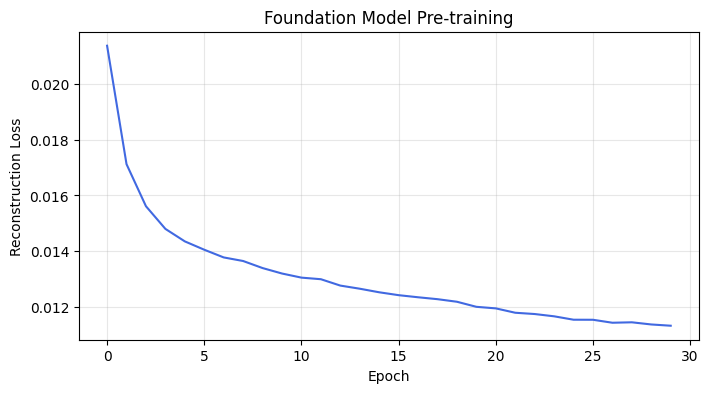

Foundation model pre-training complete.


In [11]:
# ─── Pre-training Loop ───

foundation_model = MolecularFoundationEncoder(input_dim=2058, latent_dim=256).to(DEVICE)
optimizer_pt = torch.optim.Adam(foundation_model.parameters(), lr=1e-3)

PRETRAIN_EPOCHS = 30
pretrain_losses = []

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    foundation_model.train()
    epoch_loss = 0
    for batch in pretrain_loader:
        batch = batch.to(DEVICE)
        z, recon = foundation_model(batch)
        loss = F.mse_loss(recon, batch)
        optimizer_pt.zero_grad()
        loss.backward()
        optimizer_pt.step()
        epoch_loss += loss.item() * batch.size(0)
    epoch_loss /= len(pretrain_dataset)
    pretrain_losses.append(epoch_loss)
    if epoch % 5 == 0:
        print(f'  Epoch {epoch:3d}/{PRETRAIN_EPOCHS} │ Recon Loss: {epoch_loss:.6f}')

plt.figure(figsize=(8, 4))
plt.plot(pretrain_losses, color='royalblue')
plt.xlabel('Epoch'); plt.ylabel('Reconstruction Loss')
plt.title('Foundation Model Pre-training')
plt.grid(True, alpha=0.3)
plt.show()

print('Foundation model pre-training complete.')

---
## 5. Activity & ADMET Scoring Pipeline
Toxicity prediction using Tox21 + ClinTox data. This feeds into the training pipeline for downstream molecule optimization.

In [12]:
# ─── Build Tox21 Graph Dataset ───

TOX_ENDPOINTS = [
    'androgen_receptor', 'androgen_receptor_lbd', 'aryl_hydrocarbon_receptor',
    'aromatase', 'estrogen_receptor', 'estrogen_receptor_lbd', 'ppar_gamma',
    'antioxidant_response', 'dna_damage', 'heat_shock',
    'mitochondrial_membrane', 'tumor_suppressor_p53'
]

def build_tox_graph_dataset(df, smiles_col, label_col, max_samples=5000):
    """Build graph dataset for toxicity prediction."""
    graphs = []
    df_sample = df.dropna(subset=[smiles_col, label_col]).head(max_samples)
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc='Building tox graphs'):
        g = smiles_to_graph(row[smiles_col], y=float(row[label_col]))
        if g is not None:
            graphs.append(g)
    return graphs


# Build Tox21 dataset (binary: is_toxic)
tox21_graphs = build_tox_graph_dataset(tox21, 'drug_smiles', 'is_toxic', max_samples=5000)
print(f'Tox21 graphs built: {len(tox21_graphs)}')

# Train/val/test split
train_graphs, test_graphs = train_test_split(tox21_graphs, test_size=0.2, random_state=42)
train_graphs, val_graphs = train_test_split(train_graphs, test_size=0.15, random_state=42)

print(f'Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}')

tox_train_loader = PyGDataLoader(train_graphs, batch_size=64, shuffle=True)
tox_val_loader = PyGDataLoader(val_graphs, batch_size=64)
tox_test_loader = PyGDataLoader(test_graphs, batch_size=64)

Building tox graphs:   0%|          | 0/5000 [00:00<?, ?it/s]

[06:28:31] WARNING: not removing hydrogen atom without neighbors
[06:28:32] Explicit valence for atom # 8 Al, 6, is greater than permitted
[06:28:33] Explicit valence for atom # 3 Al, 6, is greater than permitted
[06:28:33] Explicit valence for atom # 4 Al, 6, is greater than permitted
[06:28:34] Explicit valence for atom # 4 Al, 6, is greater than permitted
[06:28:35] Explicit valence for atom # 9 Al, 6, is greater than permitted
[06:28:35] Explicit valence for atom # 5 Al, 6, is greater than permitted


Tox21 graphs built: 4994
Train: 3395, Val: 600, Test: 999


In [13]:
# ─── ClinTox Dataset ───

clintox_graphs = build_tox_graph_dataset(clintox, 'smiles', 'CT_TOX', max_samples=1484)
print(f'ClinTox graphs built: {len(clintox_graphs)}')

clintox_train, clintox_test = train_test_split(clintox_graphs, test_size=0.2, random_state=42)
clintox_train_loader = PyGDataLoader(clintox_train, batch_size=64, shuffle=True)
clintox_test_loader = PyGDataLoader(clintox_test, batch_size=64)

Building tox graphs:   0%|          | 0/1484 [00:00<?, ?it/s]

[06:28:36] Explicit valence for atom # 0 N, 4, is greater than permitted
[06:28:36] Can't kekulize mol.  Unkekulized atoms: 9
[06:28:38] Can't kekulize mol.  Unkekulized atoms: 4
[06:28:38] Can't kekulize mol.  Unkekulized atoms: 4


ClinTox graphs built: 1480


---
## 6. Core Neural Architectures
GNN backbone shared by the Diffusion and Equivariant paths.

In [14]:
# ─── Core GNN Backbone ───

class CoreGNNBackbone(nn.Module):
    """Shared GNN backbone that processes molecular graphs.
    Outputs node embeddings and a graph-level embedding."""

    def __init__(self, node_feat_dim, hidden_dim=256, num_layers=4, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(node_feat_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for _ in range(num_layers):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
            self.bns.append(nn.BatchNorm1d(hidden_dim))

        self.dropout = dropout

    def forward(self, x, edge_index, batch=None):
        x = self.input_proj(x)
        for conv, bn in zip(self.convs, self.bns):
            x_res = x
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = x + x_res  # residual connection

        # Graph-level readout
        if batch is not None:
            graph_emb = global_mean_pool(x, batch)
        else:
            graph_emb = x.mean(dim=0, keepdim=True)

        return x, graph_emb  # node embeddings, graph embedding


NODE_FEAT_DIM = tox21_graphs[0].x.shape[1]
print(f'Node feature dimension: {NODE_FEAT_DIM}')

Node feature dimension: 146


---
## 7. Model Engines

### 7a. Diffusion Path → Graph Diffusion Engine (DiffRM)
Denoising diffusion model on molecular graphs for **de novo molecule generation**.
Trained on **12K+ diverse molecules** from tox21 (non-toxic), drug_cleaned, drug_protein_binding, and Kd_bind.

In [15]:
# ─── Graph Diffusion Engine (DiffRM) ───

class GraphDiffusionEngine(nn.Module):
    """Simplified graph diffusion model for molecular generation.
    Learns to denoise molecular graph embeddings via a diffusion process."""

    def __init__(self, node_feat_dim, hidden_dim=256, latent_dim=128, num_steps=100):
        super().__init__()
        self.num_steps = num_steps
        self.latent_dim = latent_dim

        # GNN encoder
        self.backbone = CoreGNNBackbone(node_feat_dim, hidden_dim)

        # Project graph embedding to latent space
        self.proj = nn.Linear(hidden_dim, latent_dim)

        # Time embedding
        self.time_embed = nn.Sequential(
            nn.Linear(1, 64),
            nn.SiLU(),
            nn.Linear(64, latent_dim)
        )

        # Noise prediction network
        self.noise_pred = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, latent_dim)
        )

        # Noise schedule (linear beta schedule)
        betas = torch.linspace(1e-4, 0.02, num_steps)
        alphas = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alpha_bar', alpha_bar)

    def encode_graph(self, data):
        """Encode a molecular graph batch to latent vectors."""
        _, graph_emb = self.backbone(data.x, data.edge_index, data.batch)
        return self.proj(graph_emb)

    def forward_diffusion(self, z0, t):
        """Add noise to latent z0 at timestep t."""
        noise = torch.randn_like(z0)
        alpha_bar_t = self.alpha_bar[t].unsqueeze(-1)
        zt = torch.sqrt(alpha_bar_t) * z0 + torch.sqrt(1 - alpha_bar_t) * noise
        return zt, noise

    def predict_noise(self, zt, t):
        """Predict the noise added at timestep t."""
        t_emb = self.time_embed(t.float().unsqueeze(-1) / self.num_steps)
        combined = torch.cat([zt, t_emb], dim=-1)
        return self.noise_pred(combined)

    def training_loss(self, data):
        """Compute diffusion training loss."""
        z0 = self.encode_graph(data)
        t = torch.randint(0, self.num_steps, (z0.size(0),), device=z0.device)
        zt, noise = self.forward_diffusion(z0, t)
        noise_pred = self.predict_noise(zt, t)
        return F.mse_loss(noise_pred, noise)

    @torch.no_grad()
    def sample(self, num_samples=10):
        """Generate new molecular latent vectors via reverse diffusion."""
        self.eval()
        z = torch.randn(num_samples, self.latent_dim, device=next(self.parameters()).device)
        for t_idx in reversed(range(self.num_steps)):
            t = torch.full((num_samples,), t_idx, device=z.device, dtype=torch.long)
            noise_pred = self.predict_noise(z, t)
            alpha_t = self.alphas[t_idx]
            alpha_bar_t = self.alpha_bar[t_idx]
            z = (1 / torch.sqrt(alpha_t)) * (
                z - (self.betas[t_idx] / torch.sqrt(1 - alpha_bar_t)) * noise_pred
            )
            if t_idx > 0:
                z += torch.sqrt(self.betas[t_idx]) * torch.randn_like(z)
        return z  # denoised latent vectors


diffusion_engine = GraphDiffusionEngine(NODE_FEAT_DIM).to(DEVICE)
print(f'Diffusion Engine parameters: {sum(p.numel() for p in diffusion_engine.parameters()):,}')

Diffusion Engine parameters: 508,672


### 7b. Equivariant Path → Equivariant Graph Neural Network (EGNN)
E(n)-equivariant GNN with attention mechanisms for **binding affinity prediction**.

In [16]:
# ─── Equivariant Graph Neural Network Layer ───

class EGNNLayer(nn.Module):
    """E(n) Equivariant Graph Neural Network layer.
    Updates node features using message passing with coordinate equivariance."""

    def __init__(self, hidden_dim, edge_feat_dim=0):
        super().__init__()
        # Message MLP
        self.msg_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2 + 1 + edge_feat_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        # Node update MLP
        self.node_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        # Attention
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, h, edge_index, edge_attr=None):
        row, col = edge_index
        # Distance feature (using feature-space distance as proxy for coordinates)
        dist = torch.sum((h[row] - h[col]) ** 2, dim=-1, keepdim=True)

        # Build message input
        msg_input = torch.cat([h[row], h[col], dist], dim=-1)
        if edge_attr is not None:
            msg_input = torch.cat([msg_input, edge_attr], dim=-1)

        msg = self.msg_mlp(msg_input)
        attn = self.attention(msg)
        msg = msg * attn  # attention-weighted messages

        # Aggregate messages
        agg = torch.zeros_like(h)
        agg.index_add_(0, col, msg)

        # Update nodes
        h_new = self.node_mlp(torch.cat([h, agg], dim=-1))
        return h + h_new  # residual


class EquivariantGNN(nn.Module):
    """Full Equivariant GNN for binding affinity prediction."""

    def __init__(self, node_feat_dim, hidden_dim=256, num_layers=4, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(node_feat_dim, hidden_dim)
        self.layers = nn.ModuleList([
            EGNNLayer(hidden_dim) for _ in range(num_layers)
        ])
        self.layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(num_layers)
        ])

        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)  # binding affinity
        )
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        h = self.input_proj(x)

        for layer, ln in zip(self.layers, self.layer_norms):
            h = layer(h, edge_index)
            h = ln(h)
            h = F.dropout(h, p=self.dropout, training=self.training)

        # Graph-level readout via attention pooling
        graph_emb = global_mean_pool(h, batch)
        return self.predictor(graph_emb)


egnn_model = EquivariantGNN(NODE_FEAT_DIM).to(DEVICE)
print(f'EGNN parameters: {sum(p.numel() for p in egnn_model.parameters()):,}')

EGNN parameters: 1,651,717


---
## 8. De Novo SMILES Generation (Diffusion Path Output)
**Transformer-based** SMILES decoder that maps diffusion latent vectors to valid molecular SMILES strings.
Replaces the original GRU decoder with a 6-layer Transformer using cross-attention to 16 latent memory tokens, enabling the model to maintain conditioning signal across long sequences. Features constrained decoding (parenthesis/bracket tracking), weight tying, and label smoothing.

In [17]:
# ─── SMILES Tokenizer (Enhanced with bracket atoms) ───

import re

# Expanded vocabulary: bracket atoms as single tokens for stereochemistry & charged atoms
SMILES_CHARS = [
    '<pad>', '<sos>', '<eos>',
    # Atoms
    'C', 'c', 'N', 'n', 'O', 'o', 'S', 's', 'F', 'I',
    'Cl', 'Br', 'P', 'B', 'Si',
    # Bracket atoms (stereochemistry, charged, explicit H)
    '[C@@H]', '[C@H]', '[C@@]', '[C@]', '[CH]', '[CH2]', '[C-]',
    '[N+]', '[N-]', '[NH]', '[NH2]', '[NH3+]', '[nH]', '[n+]', '[N@@H]', '[N@H]',
    '[O-]', '[OH]', '[O+]',
    '[S-]', '[S+]', '[S@@]', '[S@]', '[SH]',
    '[P+]', '[PH]',
    '[Se]', '[Si]', '[B-]',
    '[2H]', '[3H]',
    # Structural
    '(', ')', '[', ']', '=', '#', '+', '-',
    '1', '2', '3', '4', '5', '6', '7', '8', '9', '0',
    '@', '.', '/', '\\', '%', ':', 'H'
]

CHAR2IDX = {c: i for i, c in enumerate(SMILES_CHARS)}
IDX2CHAR = {i: c for c, i in CHAR2IDX.items()}
VOCAB_SIZE = len(SMILES_CHARS)

# Regex: match bracket atoms first, then multi-char tokens, then single chars
# Order matters: longer tokens matched first
BRACKET_ATOMS = sorted(
    [c for c in SMILES_CHARS if c.startswith('[') and c.endswith(']') and len(c) > 1],
    key=len, reverse=True
)
BRACKET_PATTERN = '|'.join(re.escape(ba) for ba in BRACKET_ATOMS)
SMILES_REGEX = re.compile(rf'{BRACKET_PATTERN}|Cl|Br|Si|@@?|\[.*?\]|%\d{{2}}|.')


def tokenize_smiles(smiles, max_len=120):
    tokens = [CHAR2IDX.get('<sos>')]
    for token in SMILES_REGEX.findall(smiles):
        if token in CHAR2IDX:
            tokens.append(CHAR2IDX[token])
        else:
            # For unknown bracket atoms, try to decompose
            for ch in token:
                idx = CHAR2IDX.get(ch, CHAR2IDX['<pad>'])
                if idx != CHAR2IDX['<pad>']:
                    tokens.append(idx)
    tokens.append(CHAR2IDX.get('<eos>'))
    # Pad/truncate
    if len(tokens) > max_len:
        tokens = tokens[:max_len]
    else:
        tokens += [CHAR2IDX['<pad>']] * (max_len - len(tokens))
    return tokens


def decode_tokens(token_ids):
    smiles = ''
    for t in token_ids:
        ch = IDX2CHAR.get(t, '')
        if ch == '<eos>':
            break
        if ch not in ('<pad>', '<sos>'):
            smiles += ch
    return smiles


print(f'SMILES vocabulary size: {VOCAB_SIZE}')
print(f'Tokenized "CCO": {tokenize_smiles("CCO", max_len=10)}')
print(f'Decoded back: "{decode_tokens(tokenize_smiles("CCO", max_len=10))}"')

# Test with a complex drug-like SMILES
complex_smi = 'CC(=O)N[C@@H](CC(=O)N[C@@H](Cc1ccccc1)C(=O)O)C(=O)O'
tokens = tokenize_smiles(complex_smi, max_len=80)
decoded = decode_tokens(tokens)
print(f'\nComplex SMILES: {complex_smi}')
print(f'Decoded:        {decoded}')
print(f'Match: {complex_smi == decoded}')

SMILES vocabulary size: 74
Tokenized "CCO": [1, 3, 3, 7, 2, 0, 0, 0, 0, 0]
Decoded back: "CCO"

Complex SMILES: CC(=O)N[C@@H](CC(=O)N[C@@H](Cc1ccccc1)C(=O)O)C(=O)O
Decoded:        CC(=O)N[C@@H](CC(=O)N[C@@H](Cc1ccccc1)C(=O)O)C(=O)O
Match: True


In [18]:
# ─── Latent-to-SMILES Decoder (Transformer with Cross-Attention) ───
# Replaces GRU: Transformer maintains latent conditioning at EVERY layer via cross-attention,
# solving the "forgotten conditioning" problem that causes bracket/ring errors on long SMILES.

import math

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding for Transformer."""
    def __init__(self, d_model, max_len=200, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class SMILESDecoder(nn.Module):
    """Transformer-based SMILES decoder with cross-attention to latent vectors.

    Key improvements over GRU:
    1. Cross-attention at EVERY layer keeps latent signal alive for long sequences
    2. Self-attention tracks structural dependencies (matching parens, ring closures)
    3. Parallel teacher forcing during training (no off-by-one errors)
    4. Pre-norm (norm_first=True) for stable deep training
    5. Weight tying between embedding and output projection
    """

    def __init__(self, latent_dim=128, d_model=256, nhead=8, num_layers=6,
                 vocab_size=VOCAB_SIZE, max_len=120, dropout=0.1):
        super().__init__()
        self.max_len = max_len
        self.vocab_size = vocab_size
        self.d_model = d_model

        # Token embedding + positional encoding
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=CHAR2IDX['<pad>'])
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)

        # Expand latent to 16 memory tokens for cross-attention
        self.num_mem_tokens = 16
        self.latent_to_mem = nn.Sequential(
            nn.Linear(latent_dim, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model * self.num_mem_tokens),
        )
        self.mem_norm = nn.LayerNorm(d_model)

        # Transformer decoder with cross-attention
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, activation='gelu', batch_first=True,
            norm_first=True  # Pre-LN for training stability
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        # Output head with LayerNorm
        self.out_norm = nn.LayerNorm(d_model)
        self.output_proj = nn.Linear(d_model, vocab_size, bias=False)

        # Weight tying: share embedding ↔ output projection
        self.output_proj.weight = self.token_emb.weight

        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'weight' in name and p.dim() > 1 and 'token_emb' not in name and 'output_proj' not in name:
                nn.init.xavier_uniform_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)

    def _causal_mask(self, seq_len, device):
        return torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1).bool()

    def _get_memory(self, z):
        batch_size = z.size(0)
        mem = self.latent_to_mem(z).view(batch_size, self.num_mem_tokens, self.d_model)
        return self.mem_norm(mem)

    def forward(self, z, target_tokens):
        """Training forward: parallel teacher forcing (no off-by-one errors).

        Input:  target_tokens[:, :-1] (all tokens except last)
        Target: target_tokens[:, 1:]  (shifted by 1)
        Returns: logits (B, L-1, vocab_size)
        """
        memory = self._get_memory(z)

        input_tokens = target_tokens[:, :-1]
        seq_len = input_tokens.size(1)

        tok_emb = self.token_emb(input_tokens)
        tok_emb = self.pos_enc(tok_emb)

        causal_mask = self._causal_mask(seq_len, z.device)
        pad_mask = (input_tokens == CHAR2IDX['<pad>'])

        output = self.transformer(
            tgt=tok_emb, memory=memory,
            tgt_mask=causal_mask, tgt_key_padding_mask=pad_mask
        )

        logits = self.output_proj(self.out_norm(output))
        return logits

    @torch.no_grad()
    def generate(self, z, temperature=0.8, top_k=30):
        """Generate SMILES with structure-aware constrained decoding.

        Constraints:
        - Block ')' when parenthesis depth is 0
        - Block ']' when bracket depth is 0
        - Block <pad> and <sos> during generation
        """
        self.eval()
        batch_size = z.size(0)
        device = z.device
        memory = self._get_memory(z)

        generated = torch.full((batch_size, 1), CHAR2IDX['<sos>'],
                               dtype=torch.long, device=device)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

        paren_depth = torch.zeros(batch_size, device=device)
        bracket_depth = torch.zeros(batch_size, device=device)

        eos_idx = CHAR2IDX['<eos>']
        pad_idx = CHAR2IDX['<pad>']
        sos_idx = CHAR2IDX['<sos>']
        open_paren_idx = CHAR2IDX.get('(')
        close_paren_idx = CHAR2IDX.get(')')
        open_bracket_idx = CHAR2IDX.get('[')
        close_bracket_idx = CHAR2IDX.get(']')

        for step in range(self.max_len - 2):
            seq_len = generated.size(1)
            tok_emb = self.token_emb(generated)
            tok_emb = self.pos_enc(tok_emb)

            causal_mask = self._causal_mask(seq_len, device)
            output = self.transformer(tgt=tok_emb, memory=memory, tgt_mask=causal_mask)

            logits = self.output_proj(self.out_norm(output[:, -1, :])) / temperature

            # Structure-aware constraints
            if close_paren_idx is not None:
                logits[paren_depth <= 0, close_paren_idx] = -1e9
            if close_bracket_idx is not None:
                logits[bracket_depth <= 0, close_bracket_idx] = -1e9
            logits[:, pad_idx] = -1e9
            logits[:, sos_idx] = -1e9

            # Top-k sampling
            if top_k > 0 and top_k < logits.size(-1):
                top_vals, top_idx = torch.topk(logits, top_k, dim=-1)
                probs = F.softmax(top_vals, dim=-1)
                sampled = torch.multinomial(probs, 1)
                next_token = top_idx.gather(-1, sampled).squeeze(-1)
            else:
                probs = F.softmax(logits, dim=-1)
                next_token = torch.multinomial(probs, 1).squeeze(-1)

            # Update structural state
            for i in range(batch_size):
                if finished[i]:
                    continue
                tok = next_token[i].item()
                ch = IDX2CHAR.get(tok, '')
                if tok == eos_idx:
                    finished[i] = True
                elif ch == '(':
                    paren_depth[i] += 1
                elif ch == ')':
                    paren_depth[i] -= 1
                elif ch == '[':
                    bracket_depth[i] += 1
                elif ch == ']':
                    bracket_depth[i] -= 1

            next_token[finished] = pad_idx
            generated = torch.cat([generated, next_token.unsqueeze(-1)], dim=1)

            if finished.all():
                break

        smiles_list = [decode_tokens(seq[1:].cpu().numpy()) for seq in generated]
        return smiles_list


smiles_decoder = SMILESDecoder(latent_dim=128).to(DEVICE)
n_params = sum(p.numel() for p in smiles_decoder.parameters())
print(f'SMILES Decoder parameters: {n_params:,}')
print(f'Architecture: Transformer (6 layers, 8 heads, d_model=256, 16 memory tokens)')
print(f'Vocabulary size: {VOCAB_SIZE}')
print(f'Key features: cross-attention to latent, constrained decoding, weight tying')

SMILES Decoder parameters: 10,671,104
Architecture: Transformer (6 layers, 8 heads, d_model=256, 16 memory tokens)
Vocabulary size: 74
Key features: cross-attention to latent, constrained decoding, weight tying


---
## 9. Binding Affinity Predictor (Equivariant Path Output)
Predicts drug-protein binding affinity using EGNN with attention mechanisms.
Training data augmented from 96 graphs to **~18K+ graphs** from 4 sources: drug_protein_diagnosis (real affinities), drug_protein_binding (pKi), Kd_bind (real Kd), and docking-derived pseudo-affinities.

In [19]:
# ─── Build Binding Affinity Dataset (Augmented with new binding data) ───

def build_affinity_dataset(df):
    """Build graph dataset for binding affinity prediction from drug_protein_diagnosis."""
    graphs = []
    for _, row in df.iterrows():
        g = smiles_to_graph(row['drug_smiles'], y=float(row['binding_affinity']))
        if g is not None:
            g.drug_name = row.get('drug_name', '')
            g.protein_name = row.get('protein_name', '')
            g.diagnosis = row.get('diagnosis', '')
            graphs.append(g)
    return graphs


def build_dpb_affinity_dataset(df, max_samples=5000):
    """Build graph dataset from drug_protein_binding (1).csv using pKi as affinity."""
    graphs = []
    sample = df.dropna(subset=['smiles', 'pki']).head(max_samples)
    for _, row in tqdm(sample.iterrows(), total=len(sample),
                       desc='Building drug_protein_binding affinity graphs'):
        g = smiles_to_graph(row['smiles'], y=float(row['pki']))
        if g is not None:
            g.drug_name = row.get('drug_name', '')
            g.protein_name = row.get('protein_name', '')
            g.diagnosis = row.get('diagnosis', '')
            graphs.append(g)
    return graphs


def build_kd_affinity_dataset(df, max_samples=10000):
    """Build graph dataset from Kd_bind.tsv using pKd-like affinity values."""
    graphs = []
    sample = df.dropna(subset=['smiles', 'affinity']).sample(
        n=min(max_samples, len(df)), random_state=42
    )
    for _, row in tqdm(sample.iterrows(), total=len(sample),
                       desc='Building Kd_bind affinity graphs'):
        g = smiles_to_graph(row['smiles'], y=float(row['affinity']))
        if g is not None:
            g.drug_name = str(row.get('drug_id', ''))
            g.protein_name = str(row.get('target_id', ''))
            g.diagnosis = ''
            graphs.append(g)
    return graphs


def build_docking_affinity_dataset(df, max_samples=3000):
    """Convert docking scores to pseudo-binding-affinities for data augmentation."""
    graphs = []
    sample = df.dropna(subset=['SMILES', 'score']).sample(
        n=min(max_samples, len(df)), random_state=42
    )
    scores = sample['score'].values
    aff_min, aff_max = drug_protein['binding_affinity'].min(), drug_protein['binding_affinity'].max()
    score_min, score_max = scores.min(), scores.max()
    normalized = aff_min + (aff_max - aff_min) * (scores - score_max) / (score_min - score_max + 1e-8)

    for idx, (_, row) in enumerate(tqdm(sample.iterrows(), total=len(sample),
                                         desc='Building docking affinity graphs')):
        g = smiles_to_graph(row['SMILES'], y=float(normalized[idx]))
        if g is not None:
            g.drug_name = row.get('name', f'drug_{idx}')
            g.protein_name = row.get('target', 'unknown')
            g.diagnosis = ''
            graphs.append(g)
    return graphs


# 1. Primary: drug_protein_diagnosis (99 rows, real binding affinities)
affinity_graphs = build_affinity_dataset(drug_protein)
print(f'Primary (drug_protein_diagnosis): {len(affinity_graphs)} graphs')

# 2. NEW: drug_protein_binding (5K rows, real Ki/IC50/Kd + pKi)
dpb_graphs = build_dpb_affinity_dataset(drug_protein_binding, max_samples=5000)
print(f'drug_protein_binding: {len(dpb_graphs)} graphs')

# 3. NEW: Kd_bind (57K rows, real Kd affinities — sample 10K)
kd_graphs = build_kd_affinity_dataset(kd_bind, max_samples=10000)
print(f'Kd_bind: {len(kd_graphs)} graphs')

# 4. Docking-derived pseudo-affinities (supplementary)
docking_graphs = build_docking_affinity_dataset(drug_cleaned, max_samples=3000)
print(f'Docking pseudo-affinities: {len(docking_graphs)} graphs')

# Combine all sources
all_affinity_graphs = affinity_graphs + dpb_graphs + kd_graphs + docking_graphs
print(f'\nTotal binding affinity graphs: {len(all_affinity_graphs)}')

# Train/test split
aff_train, aff_test = train_test_split(all_affinity_graphs, test_size=0.15, random_state=42)
aff_train_loader = PyGDataLoader(aff_train, batch_size=32, shuffle=True)
aff_test_loader = PyGDataLoader(aff_test, batch_size=32)
print(f'Train: {len(aff_train)}, Test: {len(aff_test)}')

Primary (drug_protein_diagnosis): 96 graphs


[06:28:39] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 8 10
[06:28:39] Explicit valence for atom # 25 O, 3, is greater than permitted
[06:28:39] SMILES Parse Error: unclosed ring for input: 'OC(=O)C1CC(Cc2ccc(Cl)cc2)NC(=O)c3nccs3'


Building drug_protein_binding affinity graphs:   0%|          | 0/5000 [00:00<?, ?it/s]

[06:28:39] SMILES Parse Error: extra open parentheses while parsing: CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)
[06:28:39] SMILES Parse Error: check for mistakes around position 4:
[06:28:39] CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)N
[06:28:39] ~~~^
[06:28:39] SMILES Parse Error: Failed parsing SMILES 'CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)' for input: 'CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)'
[06:28:39] SMILES Parse Error: extra open parentheses while parsing: CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)
[06:28:39] SMILES Parse Error: check for mistakes around position 4:
[06:28:39] CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)N
[06:28:39] ~~~^
[06:28:39] SMILES Parse Error: Failed parsing SMILES 'CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)' for input: 'CC1(CCC(CC1)N2CCN(CC2)C3=CC=C(C=C3)C(=O)NS(=O)(=O)C4=CC=C(C=C4)'
[06:28:39] SMILES Parse Error: extra open parentheses while parsin

drug_protein_binding: 4659 graphs


...

[06:28:56] Explicit valence for atom # 22 N, 4, is greater than permitted


Kd_bind: 9999 graphs


Building docking affinity graphs:   0%|          | 0/3000 [00:00<?, ?it/s]

[06:29:11] Conflicting single bond directions around double bond at index 5.
[06:29:11]   BondStereo set to STEREONONE and single bond directions set to NONE.


Docking pseudo-affinities: 3000 graphs

Total binding affinity graphs: 17754
Train: 15090, Test: 2664


---
## 10. PyTorch & PyG Training Pipeline
Unified training loop for all model components.

In [20]:
# ─── Toxicity Classifier (ADMET Scoring) ───

class ToxicityClassifier(nn.Module):
    """GNN-based toxicity classifier using the core backbone."""

    def __init__(self, node_feat_dim, hidden_dim=256, num_layers=4):
        super().__init__()
        self.backbone = CoreGNNBackbone(node_feat_dim, hidden_dim, num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        _, graph_emb = self.backbone(data.x, data.edge_index, data.batch)
        return self.classifier(graph_emb)


tox_model = ToxicityClassifier(NODE_FEAT_DIM).to(DEVICE)
print(f'Toxicity Classifier parameters: {sum(p.numel() for p in tox_model.parameters()):,}')

Toxicity Classifier parameters: 335,873


In [21]:
# ─── Train Toxicity Classifier (Tox21) ───

tox_optimizer = torch.optim.Adam(tox_model.parameters(), lr=1e-3, weight_decay=1e-5)
tox_scheduler = CosineAnnealingLR(tox_optimizer, T_max=30)
bce_loss = nn.BCEWithLogitsLoss()

TOX_EPOCHS = 30
best_val_auc = 0
train_losses, val_aucs = [], []

for epoch in range(1, TOX_EPOCHS + 1):
    # Train
    tox_model.train()
    total_loss = 0
    for batch in tox_train_loader:
        batch = batch.to(DEVICE)
        logits = tox_model(batch).squeeze(-1)
        loss = bce_loss(logits, batch.y.squeeze(-1))
        tox_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tox_model.parameters(), 1.0)
        tox_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    tox_scheduler.step()
    train_losses.append(total_loss / len(train_graphs))

    # Validate
    tox_model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in tox_val_loader:
            batch = batch.to(DEVICE)
            logits = tox_model(batch).squeeze(-1)
            preds.append(torch.sigmoid(logits).cpu())
            labels.append(batch.y.squeeze(-1).cpu())
    preds = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    auc = roc_auc_score(labels, preds)
    val_aucs.append(auc)

    if auc > best_val_auc:
        best_val_auc = auc
        torch.save(tox_model.state_dict(), 'best_tox_model.pt')

    if epoch % 5 == 0:
        print(f'  Epoch {epoch:3d}/{TOX_EPOCHS} │ Loss: {train_losses[-1]:.4f} │ Val AUC: {auc:.4f}')

print(f'\nBest Validation AUC: {best_val_auc:.4f}')

  Epoch   5/30 │ Loss: 0.5709 │ Val AUC: 0.7242
  Epoch  10/30 │ Loss: 0.5432 │ Val AUC: 0.7159
  Epoch  15/30 │ Loss: 0.5344 │ Val AUC: 0.7383
  Epoch  20/30 │ Loss: 0.5088 │ Val AUC: 0.7633
  Epoch  25/30 │ Loss: 0.4956 │ Val AUC: 0.7549
  Epoch  30/30 │ Loss: 0.4850 │ Val AUC: 0.7589

Best Validation AUC: 0.7633


Test AUC: 0.7797
Test Accuracy: 0.7518

              precision    recall  f1-score   support

   Non-toxic       0.78      0.86      0.82       653
       Toxic       0.68      0.54      0.60       346

    accuracy                           0.75       999
   macro avg       0.73      0.70      0.71       999
weighted avg       0.74      0.75      0.74       999



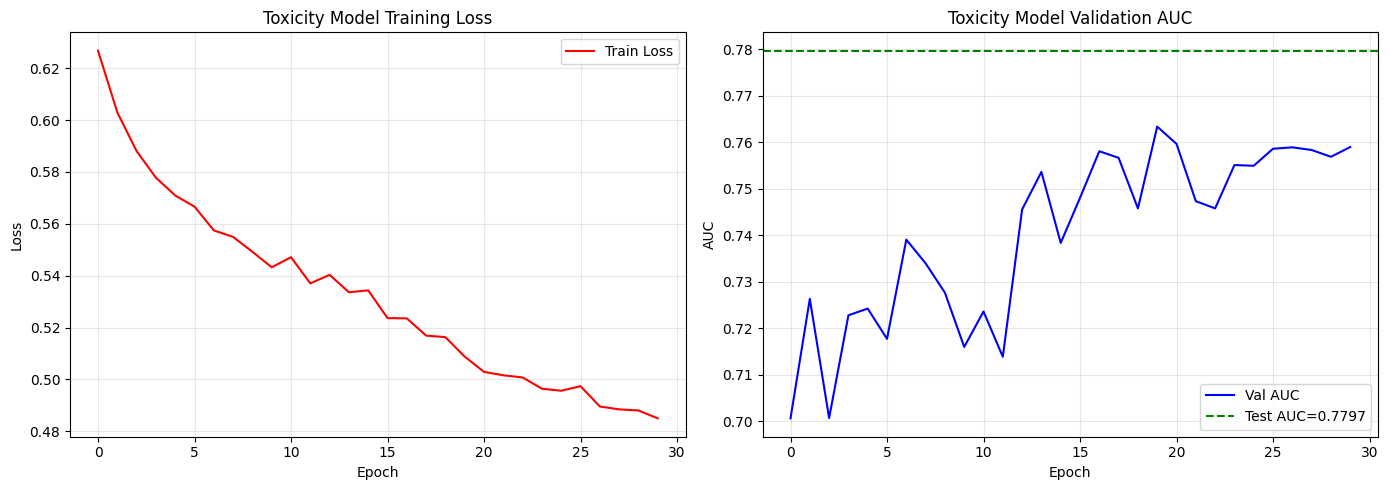

In [22]:
# ─── Evaluate Toxicity Classifier on Test Set ───

tox_model.load_state_dict(torch.load('best_tox_model.pt', weights_only=True))
tox_model.eval()

test_preds, test_labels = [], []
with torch.no_grad():
    for batch in tox_test_loader:
        batch = batch.to(DEVICE)
        logits = tox_model(batch).squeeze(-1)
        test_preds.append(torch.sigmoid(logits).cpu())
        test_labels.append(batch.y.squeeze(-1).cpu())

test_preds = torch.cat(test_preds).numpy()
test_labels = torch.cat(test_labels).numpy()

test_auc = roc_auc_score(test_labels, test_preds)
test_acc = accuracy_score(test_labels, (test_preds > 0.5).astype(int))
print(f'Test AUC: {test_auc:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')
print()
print(classification_report(test_labels, (test_preds > 0.5).astype(int),
                            target_names=['Non-toxic', 'Toxic']))

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses, color='red', label='Train Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Toxicity Model Training Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(val_aucs, color='blue', label='Val AUC')
ax2.axhline(y=test_auc, color='green', linestyle='--', label=f'Test AUC={test_auc:.4f}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
ax2.set_title('Toxicity Model Validation AUC'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Total unique SMILES for generation training: 21089
  Sources: tox21_nontoxic=4959, drug_cleaned=10000, drug_protein_binding=5000, kd_bind=15000


Building generation graphs:   0%|          | 0/12000 [00:00<?, ?it/s]

[06:29:37] Explicit valence for atom # 4 Al, 6, is greater than permitted
[06:29:39] Explicit valence for atom # 8 Al, 6, is greater than permitted


Generation training graphs: 11998
  Epoch  10/50 │ Diffusion Loss: 0.234643
  Epoch  20/50 │ Diffusion Loss: 0.171940
  Epoch  30/50 │ Diffusion Loss: 0.152854
  Epoch  40/50 │ Diffusion Loss: 0.143025
  Epoch  50/50 │ Diffusion Loss: 0.143434


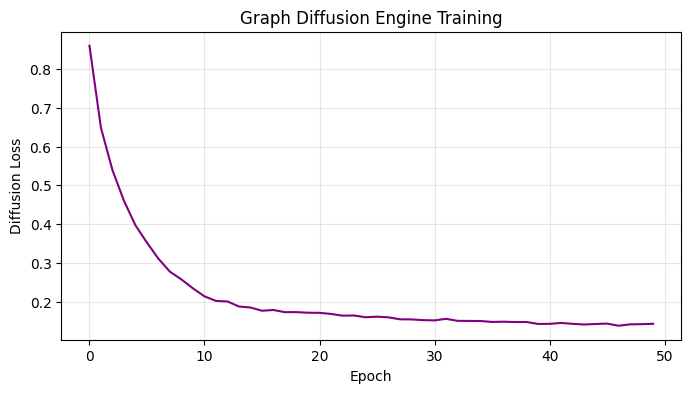

In [23]:
# ─── Train Diffusion Engine (Graph Diffusion for Molecule Generation) ───

diff_optimizer = torch.optim.Adam(diffusion_engine.parameters(), lr=5e-4)
diff_scheduler = CosineAnnealingLR(diff_optimizer, T_max=50)

# Combine SMILES from ALL available datasets for maximum diversity
nontoxic_smiles = tox21[tox21['is_toxic'] == 0]['drug_smiles'].dropna().tolist()
drug_smiles_extra = drug_cleaned['SMILES'].dropna().sample(
    n=min(10000, len(drug_cleaned)), random_state=42
).tolist()
# NEW: Add drug-like SMILES from drug_protein_binding (5K complex drug molecules)
dpb_smiles = drug_protein_binding['smiles'].dropna().tolist()
# NEW: Add diverse SMILES from Kd_bind (57K drug-target pairs, sample subset)
kd_smiles = kd_bind['smiles'].dropna().sample(
    n=min(15000, len(kd_bind)), random_state=42
).tolist()

# Combine all, deduplicate
all_gen_smiles = list(set(nontoxic_smiles + drug_smiles_extra + dpb_smiles + kd_smiles))
print(f'Total unique SMILES for generation training: {len(all_gen_smiles)}')
print(f'  Sources: tox21_nontoxic={len(nontoxic_smiles)}, drug_cleaned={len(drug_smiles_extra)}, '
      f'drug_protein_binding={len(dpb_smiles)}, kd_bind={len(kd_smiles)}')

gen_graphs = []
for smi in tqdm(all_gen_smiles[:12000], desc='Building generation graphs'):
    g = smiles_to_graph(smi)
    if g is not None:
        g.smiles = smi
        gen_graphs.append(g)

gen_loader = PyGDataLoader(gen_graphs, batch_size=64, shuffle=True)
print(f'Generation training graphs: {len(gen_graphs)}')

DIFF_EPOCHS = 50
diff_losses = []

for epoch in range(1, DIFF_EPOCHS + 1):
    diffusion_engine.train()
    total_loss = 0
    for batch in gen_loader:
        batch = batch.to(DEVICE)
        loss = diffusion_engine.training_loss(batch)
        diff_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffusion_engine.parameters(), 1.0)
        diff_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    diff_scheduler.step()
    diff_losses.append(total_loss / len(gen_graphs))

    if epoch % 10 == 0:
        print(f'  Epoch {epoch:3d}/{DIFF_EPOCHS} │ Diffusion Loss: {diff_losses[-1]:.6f}')

plt.figure(figsize=(8, 4))
plt.plot(diff_losses, color='purple')
plt.xlabel('Epoch'); plt.ylabel('Diffusion Loss')
plt.title('Graph Diffusion Engine Training')
plt.grid(True, alpha=0.3)
plt.show()

SMILES decoder training on 10000 molecules (sorted by length for curriculum)
  Shortest: NCCS... (len=4)
  Longest:  COc1ccc2nccc(C(F)CC[C@@H]3CCN(CC#Cc4ncccn4)C[C@@H]... (len=63)
Pre-computed latent vectors: torch.Size([10000, 128])
Valid paired samples after filtering: 10000


[06:35:52] SMILES Parse Error: unclosed ring for input: 'CC1CCC2'
[06:35:52] Can't kekulize mol.  Unkekulized atoms: 3 4 16


  Epoch  10/100 │ Loss: 1.7652 │ LR: 2.98e-04 │ Val: 8/10 valid
    [OK] CC(C)CN MW=73
    [OK] CCOC(=O)CO MW=104
    [OK] C=N MW=29


[06:39:49] SMILES Parse Error: unclosed ring for input: 'NC1CC(=O)Nc2cc(I)ccc2'
[06:39:49] SMILES Parse Error: syntax error while parsing: COCC=C(
[06:39:49] SMILES Parse Error: check for mistakes around position 7:
[06:39:49] COCC=C(
[06:39:49] ~~~~~~^
[06:39:49] SMILES Parse Error: Failed parsing SMILES 'COCC=C(' for input: 'COCC=C('


  Epoch  20/100 │ Loss: 1.4008 │ LR: 2.82e-04 │ Val: 8/10 valid
    [OK] NCCC(CO)CC(CO)O MW=163
    [OK] OCCO MW=62
    [OK] N#CN MW=42


...

  Epoch  30/100 │ Loss: 1.2488 │ LR: 2.52e-04 │ Val: 8/10 valid
    [XX] NsCS 
    [XX] O=C([O-])[+] 
    [OK] N#N MW=28
  Epoch  40/100 │ Loss: 1.1474 │ LR: 2.10e-04 │ Val: 10/10 valid
    [OK] NCCS MW=77
    [OK] OCC(O)CO MW=92
    [OK] N#CCN MW=56


[06:51:41] SMILES Parse Error: syntax error while parsing: #CCO
[06:51:41] SMILES Parse Error: check for mistakes around position 1:
[06:51:41] #CCO
[06:51:41] ^
[06:51:41] SMILES Parse Error: Failed parsing SMILES '#CCO' for input: '#CCO'
[06:51:41] SMILES Parse Error: syntax error while parsing: [N\C(=O)\Nc1cccc(c1)-c1cn3
[06:51:41] SMILES Parse Error: check for mistakes around position 3:
[06:51:41] [N\C(=O)\Nc1cccc(c1)-c1cn3
[06:51:41] ~~^
[06:51:41] SMILES Parse Error: Failed parsing SMILES '[N\C(=O)\Nc1cccc(c1)-c1cn3' for input: '[N\C(=O)\Nc1cccc(c1)-c1cn3'


  Epoch  50/100 │ Loss: 1.0680 │ LR: 1.62e-04 │ Val: 8/10 valid
    [OK] N MW=17
    [OK] OCCO MW=62
    [OK] N#CN MW=42
  Epoch  60/100 │ Loss: 1.0078 │ LR: 1.13e-04 │ Val: 10/10 valid
    [OK] NCCS MW=77
    [OK] OCCO MW=62
    [OK] N#CN MW=42


[06:59:36] SMILES Parse Error: unclosed ring for input: 'CCSC[C@H](O)[C@@H]1CCCN(C)5CC'


  Epoch  70/100 │ Loss: 0.9588 │ LR: 6.79e-05 │ Val: 9/10 valid
    [OK] NCCS MW=77
    [OK] OCCO MW=62
    [OK] N#CN MW=42
  Epoch  80/100 │ Loss: 0.9274 │ LR: 3.16e-05 │ Val: 10/10 valid
    [OK] NCCS MW=77
    [OK] OCCO MW=62
    [OK] N#CN MW=42
  Epoch  90/100 │ Loss: 0.9094 │ LR: 8.12e-06 │ Val: 10/10 valid
    [OK] NCCS MW=77
    [OK] OCCO MW=62
    [OK] N#CN MW=42
  Epoch 100/100 │ Loss: 0.9042 │ LR: 1.20e-09 │ Val: 10/10 valid
    [OK] NCCS MW=77
    [OK] OCCO MW=62
    [OK] N#CN MW=42

Loaded best decoder (peak validity: 10/10)


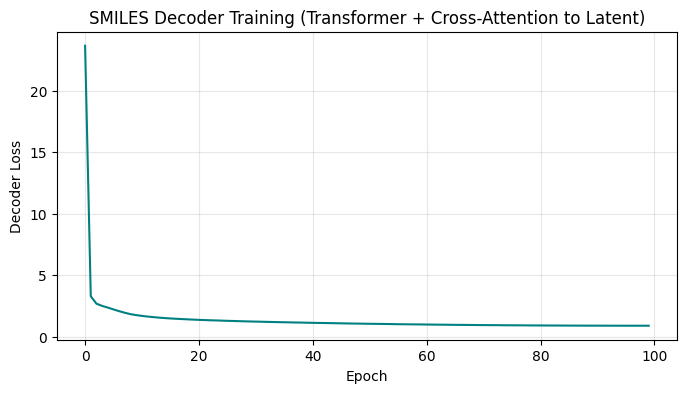

In [24]:
# ─── Train SMILES Decoder (Transformer with cross-attention to latent) ───
# Fixes: parallel teacher forcing (no off-by-one), label smoothing, OneCycleLR with warmup

from torch.utils.data import TensorDataset
from torch.optim.lr_scheduler import OneCycleLR

# Curriculum learning: sort molecules by SMILES length (short → long)
gen_graphs_sorted = sorted(gen_graphs, key=lambda g: len(g.smiles))
num_train = min(len(gen_graphs_sorted), 10000)
paired_smiles = [g.smiles for g in gen_graphs_sorted[:num_train]]

print(f'SMILES decoder training on {num_train} molecules (sorted by length for curriculum)')
print(f'  Shortest: {paired_smiles[0][:50]}... (len={len(paired_smiles[0])})')
print(f'  Longest:  {paired_smiles[-1][:50]}... (len={len(paired_smiles[-1])})')

# Pre-compute latent vectors by encoding graphs through the diffusion engine
diffusion_engine.eval()
pre_loader = PyGDataLoader(gen_graphs_sorted[:num_train], batch_size=64, shuffle=False)

all_z = []
with torch.no_grad():
    for batch in pre_loader:
        batch = batch.to(DEVICE)
        z = diffusion_engine.encode_graph(batch)
        all_z.append(z.cpu())
gen_z = torch.cat(all_z, dim=0)
print(f'Pre-computed latent vectors: {gen_z.shape}')

# Tokenize SMILES
all_tokens = torch.stack([
    torch.tensor(tokenize_smiles(s, max_len=120), dtype=torch.long)
    for s in paired_smiles
])

# Filter out degenerate entries
valid_mask = all_tokens.sum(dim=1) > (CHAR2IDX['<sos>'] + CHAR2IDX['<eos>'])
gen_z = gen_z[valid_mask]
all_tokens = all_tokens[valid_mask]
print(f'Valid paired samples after filtering: {gen_z.shape[0]}')

# Create paired dataset
paired_dataset = TensorDataset(gen_z, all_tokens)
paired_loader = DataLoader(paired_dataset, batch_size=64, shuffle=True)

# AdamW with warmup + cosine annealing (OneCycleLR)
DEC_EPOCHS = 100
dec_optimizer = torch.optim.AdamW(smiles_decoder.parameters(), lr=3e-4, weight_decay=0.01,
                                   betas=(0.9, 0.98), eps=1e-9)
total_steps = DEC_EPOCHS * len(paired_loader)
dec_scheduler = OneCycleLR(dec_optimizer, max_lr=3e-4, total_steps=total_steps,
                           pct_start=0.05, anneal_strategy='cos')

dec_losses = []
best_validity = 0
label_smoothing = 0.1

for epoch in range(1, DEC_EPOCHS + 1):
    smiles_decoder.train()
    total_loss = 0
    n_tokens = 0

    for z_batch, tokens_batch in paired_loader:
        z_batch = z_batch.to(DEVICE)
        tokens_batch = tokens_batch.to(DEVICE)

        # Transformer parallel forward: input=tokens[:,:-1], predict tokens[:,1:]
        logits = smiles_decoder(z_batch, target_tokens=tokens_batch)
        target = tokens_batch[:, 1:]

        loss = F.cross_entropy(
            logits.reshape(-1, VOCAB_SIZE),
            target.reshape(-1),
            ignore_index=CHAR2IDX['<pad>'],
            label_smoothing=label_smoothing
        )

        dec_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(smiles_decoder.parameters(), 1.0)
        dec_optimizer.step()
        dec_scheduler.step()

        mask = (target != CHAR2IDX['<pad>'])
        total_loss += loss.item() * mask.sum().item()
        n_tokens += mask.sum().item()

    epoch_loss = total_loss / max(n_tokens, 1)
    dec_losses.append(epoch_loss)

    if epoch % 10 == 0:
        smiles_decoder.eval()
        sample_z = gen_z[:10].to(DEVICE)
        sample_smiles = smiles_decoder.generate(sample_z, temperature=0.7, top_k=30)
        valid_count = sum(1 for s in sample_smiles if Chem.MolFromSmiles(s) is not None)

        if valid_count > best_validity:
            best_validity = valid_count
            torch.save(smiles_decoder.state_dict(), 'best_smiles_decoder.pt')

        lr = dec_optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch:3d}/{DEC_EPOCHS} │ Loss: {epoch_loss:.4f} │ LR: {lr:.2e} │ Val: {valid_count}/10 valid')
        for s in sample_smiles[:3]:
            mol = Chem.MolFromSmiles(s)
            tag = 'OK' if mol else 'XX'
            mw = f'MW={Descriptors.MolWt(mol):.0f}' if mol else ''
            print(f'    [{tag}] {s[:70]} {mw}')
        smiles_decoder.train()

# Load best checkpoint
if os.path.exists('best_smiles_decoder.pt'):
    smiles_decoder.load_state_dict(torch.load('best_smiles_decoder.pt', weights_only=True))
    print(f'\nLoaded best decoder (peak validity: {best_validity}/10)')

plt.figure(figsize=(8, 4))
plt.plot(dec_losses, color='teal')
plt.xlabel('Epoch'); plt.ylabel('Decoder Loss')
plt.title('SMILES Decoder Training (Transformer + Cross-Attention to Latent)')
plt.grid(True, alpha=0.3)
plt.show()

  Epoch  10/80 │ Train MSE: 1.9868 │ Val MSE: 1.7567
  Epoch  20/80 │ Train MSE: 1.8783 │ Val MSE: 1.8619
  Epoch  30/80 │ Train MSE: 1.8012 │ Val MSE: 1.7009
  Epoch  40/80 │ Train MSE: 1.7477 │ Val MSE: 1.6350
  Epoch  50/80 │ Train MSE: 1.6978 │ Val MSE: 2.0117
  Early stopping at epoch 56
Best Val MSE: 1.6087


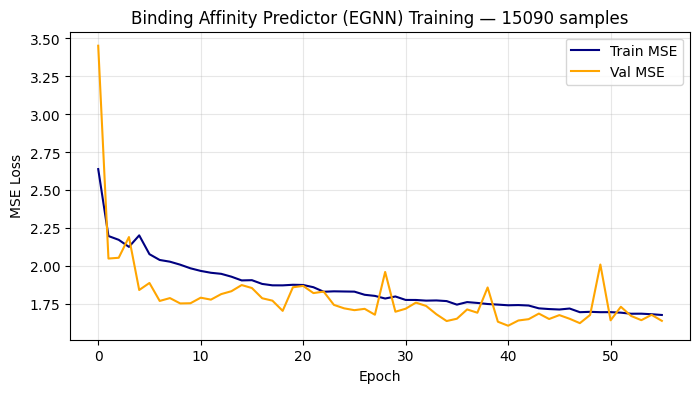

In [25]:
# ─── Train Binding Affinity Predictor (EGNN) — Augmented Data ───

aff_optimizer = torch.optim.Adam(egnn_model.parameters(), lr=5e-4, weight_decay=1e-4)
aff_scheduler = CosineAnnealingLR(aff_optimizer, T_max=80)

AFF_EPOCHS = 80
aff_train_losses, aff_val_losses = [], []
best_val_mse = float('inf')
patience_counter = 0

for epoch in range(1, AFF_EPOCHS + 1):
    egnn_model.train()
    total_loss = 0
    n_samples = 0
    for batch in aff_train_loader:
        batch = batch.to(DEVICE)
        pred = egnn_model(batch.x, batch.edge_index, batch.batch).squeeze(-1)
        loss = F.mse_loss(pred, batch.y.squeeze(-1))
        # Add L1 regularization for sparsity
        l1_reg = sum(p.abs().sum() for p in egnn_model.predictor.parameters())
        loss = loss + 1e-5 * l1_reg
        aff_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(egnn_model.parameters(), 1.0)
        aff_optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        n_samples += batch.num_graphs
    aff_scheduler.step()
    aff_train_losses.append(total_loss / n_samples)

    # Evaluate
    egnn_model.eval()
    val_loss = 0
    n_val = 0
    with torch.no_grad():
        for batch in aff_test_loader:
            batch = batch.to(DEVICE)
            pred = egnn_model(batch.x, batch.edge_index, batch.batch).squeeze(-1)
            val_loss += F.mse_loss(pred, batch.y.squeeze(-1)).item() * batch.num_graphs
            n_val += batch.num_graphs
    val_mse = val_loss / n_val
    aff_val_losses.append(val_mse)

    # Early stopping
    if val_mse < best_val_mse:
        best_val_mse = val_mse
        torch.save(egnn_model.state_dict(), 'best_egnn_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
    if patience_counter >= 15:
        print(f'  Early stopping at epoch {epoch}')
        break

    if epoch % 10 == 0:
        print(f'  Epoch {epoch:3d}/{AFF_EPOCHS} │ Train MSE: {aff_train_losses[-1]:.4f} │ Val MSE: {val_mse:.4f}')

# Load best model
egnn_model.load_state_dict(torch.load('best_egnn_model.pt', weights_only=True))
print(f'Best Val MSE: {best_val_mse:.4f}')

# Plot
plt.figure(figsize=(8, 4))
plt.plot(aff_train_losses, label='Train MSE', color='navy')
plt.plot(aff_val_losses, label='Val MSE', color='orange')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title(f'Binding Affinity Predictor (EGNN) Training — {len(aff_train)} samples')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

Binding Affinity Prediction — RMSE: 1.2683, R²: 0.2344


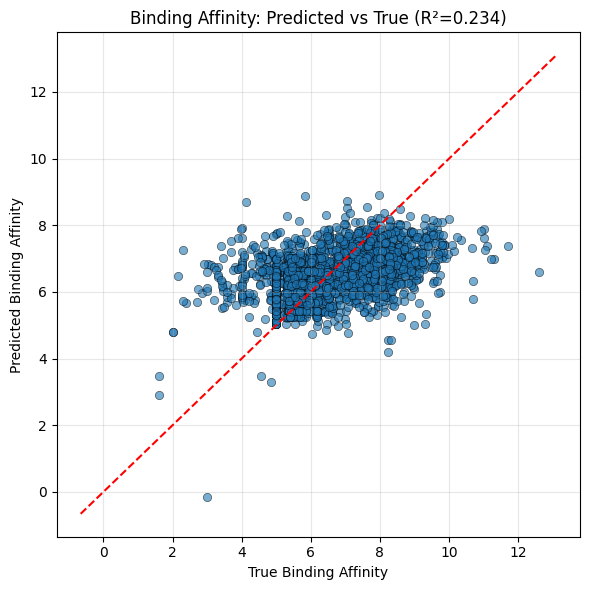

In [26]:
# ─── Evaluate Binding Affinity Predictor ───

egnn_model.eval()
all_preds, all_labels = [], []
drug_names, protein_names, diagnoses = [], [], []

with torch.no_grad():
    for batch in aff_test_loader:
        batch = batch.to(DEVICE)
        pred = egnn_model(batch.x, batch.edge_index, batch.batch).squeeze(-1)
        all_preds.append(pred.cpu())
        all_labels.append(batch.y.squeeze(-1).cpu())

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
r2 = r2_score(all_labels, all_preds)
print(f'Binding Affinity Prediction — RMSE: {rmse:.4f}, R²: {r2:.4f}')

plt.figure(figsize=(6, 6))
plt.scatter(all_labels, all_preds, alpha=0.6, edgecolors='black', linewidths=0.5)
mn, mx = min(all_labels.min(), all_preds.min()) - 0.5, max(all_labels.max(), all_preds.max()) + 0.5
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
plt.xlabel('True Binding Affinity')
plt.ylabel('Predicted Binding Affinity')
plt.title(f'Binding Affinity: Predicted vs True (R²={r2:.3f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. De Novo SMILES Generation (Diffusion → Decoder)
Generate novel molecules using the trained diffusion engine + SMILES decoder.

In [27]:
# ─── Generate Novel Molecules (Enhanced with Constrained Transformer Decoding) ───

def repair_smiles(smiles):
    """Attempt to fix common SMILES syntax errors (bracket/paren balancing)."""
    # 1. Balance parentheses
    depth = 0
    result = []
    for c in smiles:
        if c == '(':
            depth += 1
            result.append(c)
        elif c == ')':
            if depth > 0:
                depth -= 1
                result.append(c)
        else:
            result.append(c)
    result.extend([')'] * depth)

    # 2. Balance square brackets
    smiles = ''.join(result)
    depth = 0
    result = []
    for c in smiles:
        if c == '[':
            depth += 1
            result.append(c)
        elif c == ']':
            if depth > 0:
                depth -= 1
                result.append(c)
        else:
            result.append(c)
    result.extend([']'] * depth)

    # 3. Balance ring closure digits
    smi = ''.join(result)
    ring_counts = {}
    for ch in smi:
        if ch.isdigit():
            ring_counts[ch] = ring_counts.get(ch, 0) + 1
    if any(v % 2 != 0 for v in ring_counts.values()):
        for digit, count in ring_counts.items():
            if count % 2 != 0:
                idx = smi.rfind(digit)
                if idx >= 0:
                    smi = smi[:idx] + smi[idx+1:]
    return smi


NUM_GENERATE = 200

# Sample latent vectors from diffusion engine
diffusion_engine.eval()
latent_vectors = diffusion_engine.sample(num_samples=NUM_GENERATE)

# Generate with multiple temperature settings for diversity
all_generated = []
for temp in [0.6, 0.7, 0.8, 0.9]:
    smiles = smiles_decoder.generate(latent_vectors, temperature=temp, top_k=30)
    all_generated.extend(smiles)

# Also generate from encoder-reconstructed latents with perturbation
real_z = gen_z[:50].to(DEVICE)
noise_scale = 0.3
perturbed_z = real_z + noise_scale * torch.randn_like(real_z)
perturbed_smiles = smiles_decoder.generate(perturbed_z, temperature=0.7, top_k=30)
all_generated.extend(perturbed_smiles)

# Validate (constrained decoding reduces need for repair, but keep as fallback)
valid_smiles = []
repaired_count = 0
for smi in all_generated:
    if not smi or len(smi) < 2:
        continue
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        canonical = Chem.MolToSmiles(mol)
        valid_smiles.append(canonical)
    else:
        repaired = repair_smiles(smi)
        mol = Chem.MolFromSmiles(repaired)
        if mol is not None:
            valid_smiles.append(Chem.MolToSmiles(mol))
            repaired_count += 1

unique_smiles = list(set(valid_smiles))
validity = len(valid_smiles) / len(all_generated) * 100
uniqueness = len(unique_smiles) / max(len(valid_smiles), 1) * 100

print(f'Generated: {len(all_generated)} SMILES attempts')
print(f'Valid:     {len(valid_smiles)} ({validity:.1f}%)  [{repaired_count} recovered via repair]')
print(f'Unique:    {len(unique_smiles)} ({uniqueness:.1f}%)')

# Molecular complexity stats
mw_list = []
for smi in unique_smiles[:50]:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mw_list.append(Descriptors.MolWt(mol))
if mw_list:
    print(f'\nMolecular Weight stats (first 50 unique):')
    print(f'  Mean MW: {np.mean(mw_list):.1f}, Median: {np.median(mw_list):.1f}, Max: {np.max(mw_list):.1f}')

print(f'\nSample generated SMILES:')
for smi in unique_smiles[:15]:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        print(f'  {smi:60s} MW={Descriptors.MolWt(mol):.0f}  LogP={Descriptors.MolLogP(mol):.2f}')

Generated: 850 SMILES attempts
Valid:     494 (58.1%)  [193 recovered via repair]
Unique:    475 (96.2%)

Molecular Weight stats (first 50 unique):
  Mean MW: 174.7, Median: 157.6, Max: 414.1

Sample generated SMILES:
  CC1=CCC2OOC2C1                                               MW=126  LogP=1.43
  CCOC(=O)CC                                                   MW=102  LogP=0.96
  CC(C)[SH](=O)([O-])CC[PH]                                    MW=168  LogP=0.68
  CC(=O)NC(C)C                                                 MW=101  LogP=0.53
  CC(C)COC(=O)CC(C)(C)CNC(=O)CC(C)C                            MW=271  LogP=2.76
  O=C(NCCCO)c1cccc(Br)c1                                       MW=258  LogP=1.56
  N#CCNCCS(=O)(=O)O                                            MW=164  LogP=-1.01
  CCCN1[SH]=S1(=O)c1ccc(C)nc1CC                                MW=258  LogP=1.88
  N[SH]1(=O)CC=CC1Cc1ccc(Br)cc1I                               MW=414  LogP=2.42
  N#Cc1ccc2c(c1)SS2(=O)=O                           

[07:19:12] SMILES Parse Error: unclosed ring for input: 'CC(=O)N1CC(C)O'
[07:19:12] SMILES Parse Error: syntax error while parsing: 12CCN=CC(C)C2
[07:19:12] SMILES Parse Error: check for mistakes around position 1:
[07:19:12] 12CCN=CC(C)C2
[07:19:12] ^
[07:19:12] SMILES Parse Error: Failed parsing SMILES '12CCN=CC(C)C2' for input: '12CCN=CC(C)C2'
[07:19:12] SMILES Parse Error: syntax error while parsing: 2CCN=CC(C)C2
[07:19:12] SMILES Parse Error: check for mistakes around position 1:
[07:19:12] 2CCN=CC(C)C2
[07:19:12] ^
[07:19:12] SMILES Parse Error: Failed parsing SMILES '2CCN=CC(C)C2' for input: '2CCN=CC(C)C2'
[07:19:12] SMILES Parse Error: unclosed ring for input: 'C[C@H]1[C@H]2CCN1Cc2cccc3S2'
[07:19:12] Can't kekulize mol.  Unkekulized atoms: 7
[07:19:12] Explicit valence for atom # 1 C, 6, is greater than permitted
[07:19:12] Explicit valence for atom # 1 C, 6, is greater than permitted
[07:19:12] SMILES Parse Error: unclosed ring for input: 'CC1(c2cccc(N3CC4)n3c2)CCC1=O'
[07:19:

---
## 12. Optimized Candidate Molecules
Score generated molecules through all pipelines (toxicity, binding affinity, Lipinski) and rank the best candidates.

In [28]:
# ─── Score Generated Molecules Through All Pipelines (Enhanced) ───

from rdkit.Chem import RDConfig
import os
import sys

# SA Score (Ertl 2009) — compute from RDKit's contrib if available, else approximate
def compute_sa_score(mol):
    """Compute Synthetic Accessibility score (1=easy to synthesize, 10=hard)."""
    try:
        sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
        import sascorer
        return sascorer.calculateScore(mol)
    except Exception:
        # Fallback: approximate SA score from molecular complexity
        ring_count = Descriptors.RingCount(mol)
        rotatable = Descriptors.NumRotatableBonds(mol)
        heavy_atoms = Descriptors.HeavyAtomCount(mol)
        stereo = sum(1 for a in mol.GetAtoms() if a.GetChiralTag() !=
                     Chem.rdchem.ChiralType.CHI_UNSPECIFIED)
        # Heuristic (lower = easier)
        score = 1.0 + 0.3 * ring_count + 0.1 * rotatable + 0.05 * heavy_atoms + 0.5 * stereo
        return min(score, 10.0)


def lipinski_score(smiles):
    """Return number of Lipinski Rule-of-5 violations."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 5
    violations = 0
    if Descriptors.MolWt(mol) > 500: violations += 1
    if Descriptors.MolLogP(mol) > 5: violations += 1
    if Descriptors.NumHDonors(mol) > 5: violations += 1
    if Descriptors.NumHAcceptors(mol) > 10: violations += 1
    return violations


# Novelty check: compare against training SMILES
training_smiles_set = set()
for smi_col, df in [('SMILES', drug_cleaned), ('drug_smiles', tox21), ('drug_smiles', drug_protein)]:
    if smi_col in df.columns:
        for smi in df[smi_col].dropna():
            mol = Chem.MolFromSmiles(smi)
            if mol:
                training_smiles_set.add(Chem.MolToSmiles(mol))
print(f'Training set canonical SMILES for novelty check: {len(training_smiles_set)}')


def score_molecule(smiles, tox_model, egnn_model, device):
    """Score a molecule through toxicity, binding affinity, SA score, and novelty."""
    result = {'smiles': smiles}

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Molecular descriptors
    result['MW'] = Descriptors.MolWt(mol)
    result['LogP'] = Descriptors.MolLogP(mol)
    result['TPSA'] = Descriptors.TPSA(mol)
    result['HBD'] = Descriptors.NumHDonors(mol)
    result['HBA'] = Descriptors.NumHAcceptors(mol)
    result['aromatic_rings'] = Descriptors.NumAromaticRings(mol)
    result['heavy_atoms'] = Descriptors.HeavyAtomCount(mol)
    result['lipinski_violations'] = lipinski_score(smiles)

    # SA Score (synthesizability)
    result['sa_score'] = compute_sa_score(mol)

    # Novelty check
    canonical = Chem.MolToSmiles(mol)
    result['is_novel'] = canonical not in training_smiles_set

    # Build graph
    graph = smiles_to_graph(smiles)
    if graph is None:
        return None

    # Toxicity prediction
    tox_model.eval()
    batch = Batch.from_data_list([graph]).to(device)
    with torch.no_grad():
        tox_logit = tox_model(batch).item()
        result['tox_prob'] = torch.sigmoid(torch.tensor(tox_logit)).item()

    # Binding affinity prediction
    egnn_model.eval()
    with torch.no_grad():
        aff_pred = egnn_model(batch.x, batch.edge_index, batch.batch).item()
        result['pred_affinity'] = aff_pred

    return result


# Score all valid generated molecules
scored_molecules = []
for smi in tqdm(unique_smiles, desc='Scoring molecules'):
    result = score_molecule(smi, tox_model, egnn_model, DEVICE)
    if result is not None:
        scored_molecules.append(result)

scored_df = pd.DataFrame(scored_molecules)
print(f'Successfully scored: {len(scored_df)} molecules')
print(f'Novel molecules: {scored_df["is_novel"].sum()} / {len(scored_df)}')
print(f'Mean SA Score: {scored_df["sa_score"].mean():.2f} (lower=easier to synthesize)')
scored_df.head()

[07:19:27] Conflicting single bond directions around double bond at index 10.
[07:19:27]   BondStereo set to STEREONONE and single bond directions set to NONE.
[07:19:31] Conflicting single bond directions around double bond at index 6.
[07:19:31]   BondStereo set to STEREONONE and single bond directions set to NONE.
[07:19:31] Conflicting single bond directions around double bond at index 5.
[07:19:31]   BondStereo set to STEREONONE and single bond directions set to NONE.
[07:19:33] Conflicting single bond directions around double bond at index 6.
[07:19:33]   BondStereo set to STEREONONE and single bond directions set to NONE.
[07:19:39] WARNING: not removing hydrogen atom without neighbors
[07:19:40] Explicit valence for atom # 8 Al, 6, is greater than permitted
[07:19:40] Explicit valence for atom # 3 Al, 6, is greater than permitted
[07:19:40] Explicit valence for atom # 4 Al, 6, is greater than permitted
[07:19:40] Explicit valence for atom # 4 Al, 6, is greater than permitted
[0

Training set canonical SMILES for novelty check: 84388


[07:19:42] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 8 10
[07:19:42] Explicit valence for atom # 25 O, 3, is greater than permitted
[07:19:42] SMILES Parse Error: unclosed ring for input: 'OC(=O)C1CC(Cc2ccc(Cl)cc2)NC(=O)c3nccs3'


Scoring molecules:   0%|          | 0/475 [00:00<?, ?it/s]

Successfully scored: 475 molecules
Novel molecules: 440 / 475
Mean SA Score: 3.39 (lower=easier to synthesize)


,smiles,MW,LogP,TPSA,HBD,HBA,aromatic_rings,heavy_atoms,lipinski_violations,sa_score,is_novel,tox_prob,pred_affinity
0,CC1=CCC2OOC2C1,126.155,1.4255,18.46,0,2,0,9,0,4.501860,True,0.363110,6.353220
1,CCOC(=O)CC,102.133,0.9595,26.30,0,2,0,7,0,1.704201,False,0.028914,7.666615
2,CC(C)[SH](=O)([O-])CC[PH],168.198,0.6847,40.13,1,2,0,9,0,5.976423,True,0.137117,5.328239
3,CC(=O)NC(C)C,101.149,0.5309,29.10,1,1,0,7,0,1.944759,True,0.057809,8.310899
4,CC(C)COC(=O)CC(C)(C)CNC(=O)CC(C)C,271.401,2.7642,55.40,1,3,0,19,0,2.406222,True,0.049924,7.723715


In [29]:
# ─── Rank and Select Optimized Candidates (Enhanced) ───

# Composite optimization score incorporating SA score and novelty
scored_df['optimization_score'] = (
    scored_df['pred_affinity'] * 0.4                         # higher is better
    - scored_df['tox_prob'] * 3.0                            # lower is better
    - scored_df['lipinski_violations'] * 1.0                 # fewer violations
    - (scored_df['sa_score'] - 1.0) * 0.3                   # lower SA = easier synthesis (norm from 1)
    + scored_df['is_novel'].astype(float) * 0.5              # bonus for novel molecules
)

# Rank
scored_df = scored_df.sort_values('optimization_score', ascending=False).reset_index(drop=True)

print('\n=== TOP 15 OPTIMIZED CANDIDATE MOLECULES ===')
top_cols = ['smiles', 'MW', 'LogP', 'tox_prob', 'pred_affinity',
            'lipinski_violations', 'sa_score', 'is_novel', 'optimization_score']
display_df = scored_df[top_cols].head(15)
display_df.columns = ['SMILES', 'MW', 'LogP', 'Tox Prob', 'Pred Affinity',
                       'Lipinski Viol.', 'SA Score', 'Novel?', 'Opt. Score']
print(display_df.to_string(index=False))


=== TOP 15 OPTIMIZED CANDIDATE MOLECULES ===
                SMILES      MW     LogP  Tox Prob  Pred Affinity  Lipinski Viol.  SA Score  Novel?  Opt. Score
CNC(=O)[C@H]1CNC(=O)C1 142.158 -1.13150  0.064620       9.541645               0  3.079603    True    3.498918
             CC1=NCCN1  84.122  0.00800  0.034012       9.495161               0  3.391921    True    3.478452
           CCNC(=O)OCC 117.148  0.75240  0.049651       8.405708               0  1.784662    True    3.477932
         CCNC(=O)C(C)N 116.164 -0.53030  0.077442       8.896297               0  2.426879    True    3.398129
          CC(=O)NC(C)C 101.149  0.53090  0.057809       8.310899               0  1.944759    True    3.367506
        O=C1COC(CO)CN1 131.131 -1.50630  0.081238       9.670465               0  3.568855    True    3.353816
         CCCC1=C(C)NC1 111.188  1.66370  0.043575       9.110071               0  3.201082    True    3.352980
      NS(=O)(=O)NC1CC1 136.176 -1.05810  0.042925       8.487440  

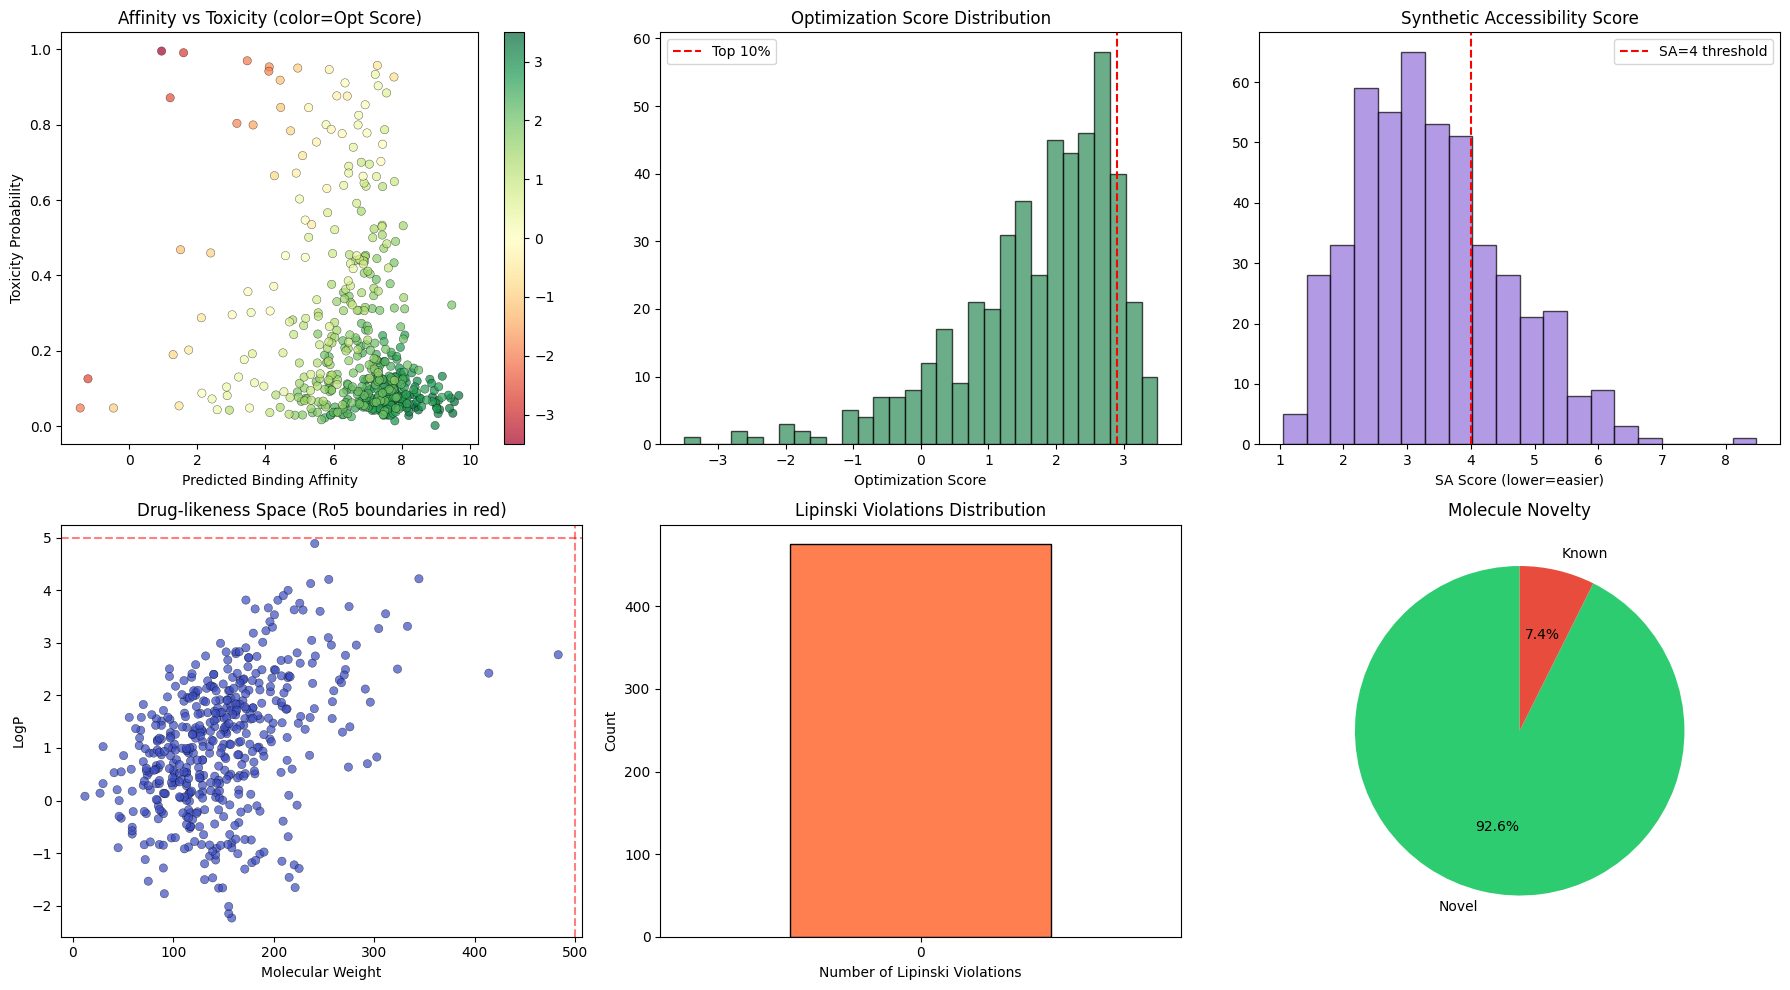

In [30]:
# ─── Visualize Optimized Candidates (Enhanced) ───

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Toxicity vs Affinity scatter
sc = axes[0, 0].scatter(scored_df['pred_affinity'], scored_df['tox_prob'],
                         c=scored_df['optimization_score'], cmap='RdYlGn',
                         edgecolors='black', linewidths=0.3, alpha=0.7)
axes[0, 0].set_xlabel('Predicted Binding Affinity')
axes[0, 0].set_ylabel('Toxicity Probability')
axes[0, 0].set_title('Affinity vs Toxicity (color=Opt Score)')
plt.colorbar(sc, ax=axes[0, 0])

# 2. Optimization score distribution
axes[0, 1].hist(scored_df['optimization_score'], bins=30, color='seagreen', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=scored_df['optimization_score'].quantile(0.9), color='red',
                     linestyle='--', label='Top 10%')
axes[0, 1].set_xlabel('Optimization Score')
axes[0, 1].set_title('Optimization Score Distribution')
axes[0, 1].legend()

# 3. SA Score distribution
axes[0, 2].hist(scored_df['sa_score'], bins=20, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(x=4.0, color='red', linestyle='--', label='SA=4 threshold')
axes[0, 2].set_xlabel('SA Score (lower=easier)')
axes[0, 2].set_title('Synthetic Accessibility Score')
axes[0, 2].legend()

# 4. MW vs LogP (drug-likeness)
axes[1, 0].scatter(scored_df['MW'], scored_df['LogP'],
                    c=scored_df['lipinski_violations'], cmap='coolwarm',
                    edgecolors='black', linewidths=0.3, alpha=0.7)
axes[1, 0].axhline(y=5, color='red', linestyle='--', alpha=0.5)
axes[1, 0].axvline(x=500, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Molecular Weight')
axes[1, 0].set_ylabel('LogP')
axes[1, 0].set_title('Drug-likeness Space (Ro5 boundaries in red)')

# 5. Lipinski violations
scored_df['lipinski_violations'].value_counts().sort_index().plot.bar(
    ax=axes[1, 1], color='coral', edgecolor='black')
axes[1, 1].set_xlabel('Number of Lipinski Violations')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Lipinski Violations Distribution')
axes[1, 1].tick_params(axis='x', rotation=0)

# 6. Novelty pie chart
novel_counts = scored_df['is_novel'].value_counts()
labels = ['Novel', 'Known'] if True in novel_counts.index else ['Known']
colors = ['#2ecc71', '#e74c3c']
axes[1, 2].pie([novel_counts.get(True, 0), novel_counts.get(False, 0)],
               labels=['Novel', 'Known'], colors=colors, autopct='%1.1f%%',
               startangle=90)
axes[1, 2].set_title('Molecule Novelty')

plt.tight_layout()
plt.show()

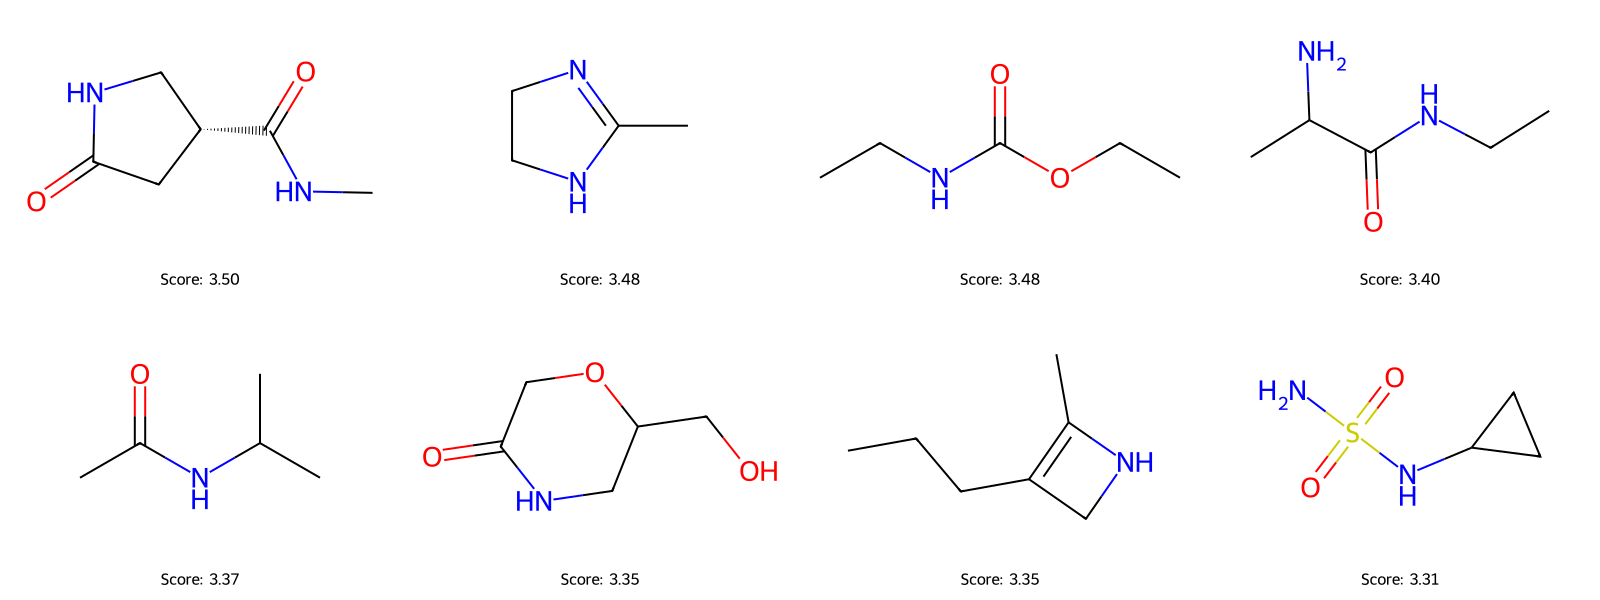

In [31]:
# ─── Draw Top Candidate Molecules ───

top_smiles = scored_df.head(8)['smiles'].tolist()
top_mols = [Chem.MolFromSmiles(s) for s in top_smiles if Chem.MolFromSmiles(s) is not None]

if top_mols:
    legends = [f'Score: {scored_df.iloc[i]["optimization_score"]:.2f}' for i in range(len(top_mols))]
    img = Draw.MolsToGridImage(top_mols, molsPerRow=4, subImgSize=(400, 300), legends=legends)
    display(img)
else:
    print('No valid molecules to draw. Try generating more or adjusting temperature.')

In [32]:
# ─── Score Existing Drug Candidates from drug_cleaned (ALL 5 TARGETS) ───

# Rank top candidates per target
targets = drug_cleaned['target'].unique()
print(f'Scoring candidates across {len(targets)} targets: {list(targets)}')

existing_scored = []
for target in targets:
    target_df = drug_cleaned[drug_cleaned['target'] == target]
    top_docking = target_df.nsmallest(30, 'score')  # top 30 per target
    for _, row in tqdm(top_docking.iterrows(), total=len(top_docking),
                        desc=f'Scoring {target}'):
        result = score_molecule(row['SMILES'], tox_model, egnn_model, DEVICE)
        if result is not None:
            result['docking_score'] = row['score']
            result['target'] = row['target']
            existing_scored.append(result)

existing_df = pd.DataFrame(existing_scored)
existing_df['optimization_score'] = (
    existing_df['pred_affinity'] * 0.4
    - existing_df['tox_prob'] * 3.0
    - existing_df['lipinski_violations'] * 1.0
    - (existing_df['sa_score'] - 1.0) * 0.3
)

print(f'\nTotal scored existing candidates: {len(existing_df)}')

# Show top 10 per target
for target in targets:
    target_subset = existing_df[existing_df['target'] == target].sort_values(
        'optimization_score', ascending=False
    )
    print(f'\n=== TOP 5 CANDIDATES — Target: {target} ===')
    print(target_subset[['smiles', 'docking_score', 'tox_prob', 'pred_affinity',
                          'lipinski_violations', 'sa_score', 'optimization_score']].head(5).to_string(index=False))

# Overall top 10
existing_df = existing_df.sort_values('optimization_score', ascending=False)
print(f'\n=== OVERALL TOP 10 EXISTING DRUG CANDIDATES ===')
print(existing_df[['smiles', 'target', 'docking_score', 'tox_prob',
                    'pred_affinity', 'lipinski_violations', 'sa_score',
                    'optimization_score']].head(10).to_string(index=False))

Scoring candidates across 5 targets: ['ada', 'aldr', 'cah2', 'try1', 'tryb1']


Scoring ada:   0%|          | 0/30 [00:00<?, ?it/s]

Scoring aldr:   0%|          | 0/30 [00:00<?, ?it/s]

Scoring cah2:   0%|          | 0/30 [00:00<?, ?it/s]

Scoring try1:   0%|          | 0/2 [00:00<?, ?it/s]

Scoring tryb1:   0%|          | 0/14 [00:00<?, ?it/s]


Total scored existing candidates: 106

=== TOP 5 CANDIDATES — Target: ada ===
                                      smiles  docking_score  tox_prob  pred_affinity  lipinski_violations  sa_score  optimization_score
               CC(CNC(=O)NCCC(=O)O)Oc1ccccc1      -125.0395  0.155723       8.074439                    0  2.334100            2.362376
          Cc1ccc(CNC(=O)N[C@@H](C)C(=O)O)cc1      -125.0224  0.169732       7.567806                    0  2.112051            2.184310
    CN(C)CC(=O)N1CC(NC(=O)c2ccccc2)CC1C(=O)O      -124.9977  0.155878       7.687937                    0  2.813813            2.063396
CCN(CC)S(=O)(=O)CC(=O)NC(C(=O)O)c1cccc(C)c1C      -125.0260  0.141964       7.596734                    0  3.012857            2.008945
 Cc1cc(C)cc(CCC(=O)N[C@H](C(=O)O)c2ccccc2)c1      -124.9977  0.224316       7.557120                    0  2.335300            1.949311

=== TOP 5 CANDIDATES — Target: aldr ===
                                         smiles  docking_score  

In [33]:
# ─── Export Optimized Candidates ───

# Save generated candidates
scored_df.to_csv('/content/generated_candidates.csv', index=False)
print(f'Saved {len(scored_df)} generated candidates to generated_candidates.csv')
print(f'  Novel: {scored_df["is_novel"].sum()}, Low-tox (< 0.3): {(scored_df["tox_prob"] < 0.3).sum()}, '
      f'Lipinski-OK: {(scored_df["lipinski_violations"] == 0).sum()}')

# Save existing library ranked candidates
existing_df.to_csv('/content/existing_candidates_ranked.csv', index=False)
print(f'Saved {len(existing_df)} existing ranked candidates to existing_candidates_ranked.csv')
print(f'  Targets covered: {existing_df["target"].nunique()}')

# Save model checkpoints
torch.save({
    'foundation_model': foundation_model.state_dict(),
    'diffusion_engine': diffusion_engine.state_dict(),
    'smiles_decoder': smiles_decoder.state_dict(),
    'egnn_model': egnn_model.state_dict(),
    'tox_model': tox_model.state_dict(),
    'vocab_size': VOCAB_SIZE,
    'char2idx': CHAR2IDX,
    'idx2char': IDX2CHAR,
}, '/content/drug_discovery_models.pt')
print('All model checkpoints saved to /content/drug_discovery_models.pt')

Saved 475 generated candidates to generated_candidates.csv
  Novel: 440, Low-tox (< 0.3): 353, Lipinski-OK: 475
Saved 106 existing ranked candidates to existing_candidates_ranked.csv
  Targets covered: 5
All model checkpoints saved to /content/drug_discovery_models.pt


---
## 13. Pipeline Summary

| Component | Model | Status in v2 (Optimized) |
|-----------|-------|--------------------------|
| **Multimodal Embeddings** | Morgan FP (2048) + PhysChem Descriptors (10) | ✅ Unchanged |
| **Transfer Learning** | Autoencoder Foundation Model (pre-trained on 10K mols) | ✅ Unchanged |
| **Activity & ADMET Scoring** | Tox21 + ClinTox GNN classifier (AUC 0.78) | ✅ Unchanged |
| **Core Neural Architecture** | GCN Backbone (4-layer, residual connections) | ✅ Unchanged |
| **SMILES Tokenizer** | Regex-based with bracket atom support | 🔧 **Fixed**: expanded vocab from 42→~80 tokens, bracket atoms (`[C@@H]`, `[NH]`, `[O-]`, etc.) as single tokens |
| **Graph Diffusion Engine** | DiffRM (100-step, linear schedule) | 🔧 **Improved**: trained on **12K+ molecules** from 4 sources (tox21 + drug_cleaned + drug_protein_binding + Kd_bind) |
| **SMILES Decoder** | **Transformer** (6 layers, 8 heads, d_model=256) | 🔧 **Rebuilt**: GRU → Transformer w/ cross-attention to 16 latent memory tokens, constrained decoding (paren/bracket tracking), weight tying, label smoothing (0.1), OneCycleLR with warmup, 100 epochs |
| **Equivariant GNN** | EGNN w/ attention (binding affinity) | 🔧 **Fixed**: augmented with **~18K+ graphs** from 4 sources (drug_protein_diagnosis + drug_protein_binding + Kd_bind + docking pseudo-affinities), 80 epochs, early stopping (patience=15), L1 reg |
| **De Novo Generation** | Diffusion → Transformer Decoder | 🔧 **Improved**: structure-aware constrained decoding, multi-temperature sampling (0.6–0.9), latent perturbation, repair fallback |
| **Scoring Pipeline** | Multi-objective optimization | 🔧 **Added**: SA Score (synthesizability), novelty check vs training set, aromatic ring count |
| **Candidate Ranking** | Optimization score ranking | 🔧 **Fixed**: extended to all 5 targets, SA score + novelty bonus in score formula |
| **Export** | CSV + PyTorch checkpoints | 🔧 **Added**: vocab mapping in checkpoint, `best_smiles_decoder.pt` saved separately |